# 2026 CITS4012 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

**Group 69 · Dataset: PIQA (Physical Interaction QA) · Main model: DACT (Difference-Aware Contrastive Transformer), trained from scratch.**

### How to run (clean Google Colab)
1. `Runtime → Change runtime type → GPU` (any GPU works: bf16 mixed precision is used on GPUs with native bf16 such as A100/L4, fp16 on others such as the free T4).
2. `Runtime → Run all`. The first data cell **downloads the four PIQA files automatically** from the unit's shared Google Drive folder (`Config.data_folder_url`). If that download fails, it falls back to the provided zip at **`MyDrive/Group69/PIQA.zip`** (mounting Google Drive), or change `Config.drive_zip`.
3. No other installation is needed: every package used (`torch`, `tokenizers`, `transformers`, `scikit-learn`, `scipy`, `pandas`, `matplotlib`) is pre-installed on Colab (only `gdown` is installed if missing); the first code cell prints the versions. The pretrained baselines (B3/B4) download `FacebookAI/roberta-base` and `Qwen/Qwen2.5-1.5B` from the Hugging Face Hub.
4. The last cell packs `outputs/` (logs, results, figures; no checkpoints) into `outputs.zip` and downloads it, and also copies it to Google Drive if Drive is mounted.

### Notes for the marker
* **Data usage.** No external data. The official PIQA training file is split 90/10 (stratified, seed 42) into *train* / *validation*. Hyper-parameter selection, early stopping and ablation comparisons use the validation split only, and test labels are used only in the clearly marked *Final test evaluation* part of Section 3. Two caveats, also stated in the report: the test file is loaded and tokenised at the start (B1/B3 compute their test predictions in Step 4 and keep them unseen until Step 5), and the decision to explore the lexical head was taken after the test results of earlier runs had been seen; its configuration was then selected on validation only. One test item also appears in the training file (disclosed, not removed).
* **From scratch.** DACT and the BiLSTM baseline start from random initialisation; their BPE tokenizer is learned from the training split only. The optional masked-LM warm-up also uses only training-split text. Pretrained models appear only as baselines (B3, B4), and every baseline number is produced by the code in this notebook.
* **Code version of the saved outputs.** The outputs in this notebook were produced by exactly the code shown (commit `0d70cdc`), in one clean top-to-bottom run on a Colab Pro **A100** (bf16 mixed precision) on 2026-10-01, executed with the Colab CLI; the data were downloaded automatically from the unit's shared folder. An earlier run of the same model on a free T4 (commit `538cf5b`) gave the same DACT test accuracy (61.6 %); its outputs are archived in `experiments/`.
* **Logs.** Every run writes a JSON-lines log (`outputs/logs/*.jsonl`) with the full config and per-epoch metrics, and result summaries to `outputs/results/*.json|csv`. When Google Drive is mounted, the last cell copies `outputs/` (without checkpoints) to `MyDrive/Group69/outputs/`. The saved logs, result tables, per-item predictions (gzip-compressed in the repository) and figures of the A100 run are submitted with this notebook in `outputs/`. (Earlier runs without the lexical head are kept in the repository history and `docs/DEVELOPMENT_LOG.md`; their numbers are not used here.)
* **Code organisation.** Model classes (`nn.Module`s) are in Section 2 (*Model Implementation*) because the notebook must run top-to-bottom; all remaining code is plain functions. The same code also exists as modules in our repository (`src/`); `python tools/sync_notebook.py` copies them into this notebook so the two cannot drift apart.
* **Revision 2.** (i) Over-long solutions are truncated *around the differing span* instead of keeping the prefix (`Config.diff_aware_truncation`, fixes the cobbler item in Section 3.3); (ii) new ablation *diff-bias prior 0* (`Config.tag_bias_init = 0`) tests whether the initial pooling bias matters; (iii) RoBERTa (B3) is fine-tuned with 3 seeds like the from-scratch models; (iv) an error-overlap analysis compares what DACT and the baselines get right; (v) attention controls separate learned attention from the built-in initial bias. All changes are recorded in `docs/DEVELOPMENT_LOG.md` (section 22).
* **Runtime.** About 1 h 50 min on a free T4 (about 6-14 s per DACT epoch, 160 s per RoBERTa epoch); about 30-35 min on an A100.

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 1.1 Environment check and configuration
All hyper-parameters live in one `Config` dataclass so that every experiment (including ablations) is a documented, logged variation of it.

In [ ]:
import os, sys, platform, importlib
SMOKE = os.environ.get("PIQA_SMOKE") == "1"   # local smoke test only; always False on Colab
for pkg in ["torch", "numpy", "sklearn", "scipy", "pandas", "matplotlib", "tokenizers", "transformers"]:
    print(f"{pkg:13s}", importlib.import_module(pkg).__version__)
import torch
print("python       ", platform.python_version())
print("GPU          ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (switch the runtime to GPU)")

torch         2.11.0+cu128
numpy         2.1.3


sklearn       1.6.1
scipy         1.16.3
pandas        2.2.3
matplotlib    3.10.0
tokenizers    0.23.1


transformers  5.16.1
python        3.13.15
GPU           NVIDIA A100-SXM4-40GB


In [ ]:
"""Global configuration, reproducibility and device helpers."""
import json
import os
import random
import time
import platform
import importlib.metadata
from dataclasses import asdict, dataclass, replace

import numpy as np
import torch


@dataclass
class Config:
    # ---- paths ----
    # PIQA sub-folder of the unit's shared A2 dataset folder; on Colab the data is downloaded from here automatically
    data_folder_url: str = "https://drive.google.com/drive/folders/1lxEsHLbRsgOHh8rOAd75QHUZds7ybKtT"
    drive_zip: str = "/content/drive/MyDrive/Group69/PIQA.zip"  # Colab location of the provided data
    local_zip_glob: str = "*.zip"                               # fallback when running outside Colab
    data_dir: str = "data/piqa"
    out_dir: str = "outputs"

    # ---- data ----
    seed: int = 42              # seed for the train/validation split (kept fixed across runs)
    val_frac: float = 0.10
    vocab_size: int = 8000
    min_frequency: int = 2
    max_goal_len: int = 40      # BPE tokens
    max_sol_len: int = 96
    diff_aware_truncation: bool = True  # over-long solutions keep the window around the differing span, not the prefix

    # ---- model (DACT) ----
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 1024
    dropout: float = 0.2
    attn_dropout: float = 0.1
    max_len: int = 160

    # ---- ablation switches ----
    use_diff_tags: bool = True        # difference-tag embedding
    use_cross_solution: bool = True   # sol1 <-> sol2 contrastive cross-attention
    pool_mode: str = "diff_attn"      # "diff_attn" | "attn" | "mean"
    tag_bias_init: float = 1.0        # initial pooling bias for difference-tagged tokens (0.0 = no built-in prior)
    use_lexical: bool = True          # "wide" head: learned weights of hashed solution unigrams/bigrams added to the score
    lex_buckets: int = 2 ** 18        # hash buckets of the lexical head
    lex_lr: float = 1e-2              # learning rate of the lexical head (the rest of the model uses `lr`)
    objective: str = "pairwise"       # "pairwise" (softmax over the two options) | "pointwise" (independent BCE)
    mlm_epochs: int = 0               # in-domain masked-LM warm-up on the training split only

    # ---- optimisation ----
    batch_size: int = 128
    lr: float = 3e-4
    weight_decay: float = 0.05
    epochs: int = 20
    warmup_ratio: float = 0.06
    label_smoothing: float = 0.1
    patience: int = 6
    grad_clip: float = 1.0
    mlm_lr: float = 5e-4
    mlm_prob: float = 0.15
    amp: bool = True
    num_workers: int = 2
    run_seed: int = 42         # model/data-loader RNG; seed above remains the fixed split seed
    deterministic: bool = False  # historical CUDA runs used fast, nondeterministic kernels
    symmetric_diff_tags: bool = False  # opt-in NEW protocol; historical results use False

    def to_dict(self):
        return asdict(self)

    def but(self, **kw):
        """Return a copy with some fields overridden (used for ablations / seeds)."""
        return replace(self, **kw)


def set_seed(seed: int, deterministic=False):
    if deterministic:
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(deterministic)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic


def environment_info(device=None):
    """Runtime provenance; recorded values describe this run, never the historical run."""
    versions = {}
    for package in ("torch", "numpy", "scikit-learn", "scipy", "pandas", "matplotlib", "tokenizers", "transformers"):
        try:
            versions[package] = importlib.metadata.version(package)
        except importlib.metadata.PackageNotFoundError:
            versions[package] = None
    return {"python": platform.python_version(), "platform": platform.platform(), "packages": versions,
            "device": str(device), "cuda": torch.version.cuda,
            "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
            "deterministic": torch.are_deterministic_algorithms_enabled()}


def get_device():
    if torch.cuda.is_available():
        # TF32 matmuls: large speed-up on Ampere+ GPUs (A100 / L4) with negligible accuracy impact
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = not torch.are_deterministic_algorithms_enabled()
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def amp_dtype(device):
    """bf16 autocast on GPUs with native bf16 (Ampere+), fp16 on older CUDA GPUs, disabled elsewhere.

    Only *native* support counts: a T4 reports bf16 as supported through emulation, which trains 3.5x slower than fp16.
    """
    if device.type != "cuda":
        return None
    return torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float16


class JsonlLogger:
    """Append-only JSON-lines logger so every training/evaluation run leaves a persistent log file."""

    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.path = path

    def log(self, **record):
        record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), **record}
        with open(self.path, "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
        return record

In [ ]:
CFG = Config()
if SMOKE:
    CFG = CFG.but(epochs=1, d_model=64, d_ff=128, n_layers=2, batch_size=32, out_dir="outputs_nbsmoke")
DEVICE = torch.device("cpu") if SMOKE else get_device()
FINAL_EVAL = False   # set to True only in Step 5; no cell may read test labels before that
os.makedirs(CFG.out_dir, exist_ok=True)
print("device:", DEVICE, "| autocast dtype:", amp_dtype(DEVICE))

device: cuda | autocast dtype: torch.bfloat16


## 1.2 Loading, splitting and tokenising PIQA
* Each item: a **goal** and two candidate **solutions**; the label says which solution is physically sensible.
* The provided `test` split (1,838 items) is only used at the very end; a stratified 10 % of the training file is held out as the **validation** split.
* **Tokenizer:** byte-pair encoding (8k merges vocabulary) *learned on the training split only*. PIQA has many rare, domain-specific words (tools, materials, recipes), so sub-words avoid a large `[UNK]` rate that a word-level vocabulary would have.
* **Difference tags:** the two solutions of an item are usually near-duplicates. We align their BPE sequences with `difflib.SequenceMatcher` and tag every solution token as *shared* or *different*. These tags are consumed by the model (Section 2).

In [ ]:
"""PIQA loading, train/validation split, BPE tokenizer, difference tags and batching."""
import difflib
import glob
import json
import os
import shutil
import subprocess
import sys
import zipfile
import hashlib

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from torch.utils.data import DataLoader, Dataset


EXPECTED_FILES = ("train.jsonl", "train-labels.lst", "test.jsonl", "test-labels.lst")
SPECIALS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
PAD, UNK, CLS, SEP, MASK = range(len(SPECIALS))

# difference-tag vocabulary
TAG_OTHER, TAG_SHARED, TAG_DIFF = 0, 1, 2   # goal/special tokens, token shared by both solutions, token unique to this solution


# ----------------------------------------------------------------------------------------------
# 1. Locating and extracting the data
# ----------------------------------------------------------------------------------------------
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_zip(cfg: Config):
    if _in_colab():
        from google.colab import drive
        if not os.path.isdir("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        if os.path.isfile(cfg.drive_zip):
            return cfg.drive_zip
        raise FileNotFoundError(f"PIQA zip not found at {cfg.drive_zip}. Update Config.drive_zip.")
    for path in [cfg.drive_zip, *sorted(glob.glob(cfg.local_zip_glob))]:
        if os.path.isfile(path) and zipfile.is_zipfile(path):
            with zipfile.ZipFile(path) as zf:
                names = {os.path.basename(n) for n in zf.namelist()}
            if set(EXPECTED_FILES) <= names:
                return path
    raise FileNotFoundError("No zip containing the PIQA files was found.")


def download_piqa(cfg: Config):
    """Downloads the four PIQA files from the unit's shared (public) Google Drive folder; True on success."""
    tmp = cfg.data_dir + "_download"
    try:
        try:
            import gdown
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        gdown.download_folder(url=cfg.data_folder_url, output=tmp, quiet=True)
    except Exception as e:  # missing package, network or Drive quota problems: fall back to the zip
        print(f"Download from the shared folder failed ({e}); falling back to the data zip.")
        return False
    found = {os.path.basename(p): p for p in glob.glob(os.path.join(tmp, "**", "*"), recursive=True)}
    if not set(EXPECTED_FILES) <= set(found):
        return False
    os.makedirs(cfg.data_dir, exist_ok=True)
    for fname in EXPECTED_FILES:
        shutil.move(found[fname], os.path.join(cfg.data_dir, fname))
    shutil.rmtree(tmp, ignore_errors=True)
    print(f"Downloaded {EXPECTED_FILES} from the unit's shared folder -> {cfg.data_dir}")
    return True


def prepare_data(cfg: Config):
    """Puts the four PIQA files into cfg.data_dir: existing copy, else (on Colab) the shared folder, else the zip."""
    if all(os.path.isfile(os.path.join(cfg.data_dir, f)) for f in EXPECTED_FILES):
        return cfg.data_dir
    if _in_colab() and cfg.data_folder_url and download_piqa(cfg):
        return cfg.data_dir
    zpath = _find_zip(cfg)
    os.makedirs(cfg.data_dir, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = {os.path.basename(n): n for n in zf.namelist() if not n.endswith("/")}
        for fname in EXPECTED_FILES:
            with zf.open(members[fname]) as src, open(os.path.join(cfg.data_dir, fname), "wb") as dst:
                dst.write(src.read())
    print(f"Extracted {EXPECTED_FILES} from {zpath} -> {cfg.data_dir}")
    return cfg.data_dir


def load_split(data_dir, split):
    with open(os.path.join(data_dir, f"{split}.jsonl"), encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    with open(os.path.join(data_dir, f"{split}-labels.lst"), encoding="utf-8") as f:
        labels = [int(line) for line in f if line.strip()]
    if len(rows) != len(labels):
        raise ValueError(f"{split}: {len(rows)} rows vs {len(labels)} labels")
    for i, (r, y) in enumerate(zip(rows, labels)):
        if y not in (0, 1):
            raise ValueError(f"{split} row {i}: label must be 0 or 1")
        r["label"] = y
        for k in ("goal", "sol1", "sol2"):
            if not isinstance(r.get(k), str) or not r[k].strip():
                raise ValueError(f"{split} row {i}: {k} must be a nonempty string")
            r[k] = " ".join(r[k].split())  # collapse irregular whitespace
    return rows


def load_piqa(cfg: Config):
    """Returns train / validation (held out from the official training file) / test.

    The test split is returned separately and must only be used for the final evaluation.
    """
    data_dir = prepare_data(cfg)
    full_train = load_split(data_dir, "train")
    test = load_split(data_dir, "test")
    idx = np.arange(len(full_train))
    tr_idx, va_idx = train_test_split(idx, test_size=cfg.val_frac, random_state=cfg.seed,
                                      stratify=[r["label"] for r in full_train])
    train = [full_train[i] for i in tr_idx]
    val = [full_train[i] for i in va_idx]
    return train, val, test


# ----------------------------------------------------------------------------------------------
# 2. Tokenizer (BPE learned from the training split only)
# ----------------------------------------------------------------------------------------------
def train_tokenizer(train_rows, cfg: Config, path=None):
    if path and os.path.exists(path):
        raise FileExistsError(f"Tokenizer evidence already exists: {path}. Use a fresh output directory.")
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
    tok.pre_tokenizer = pre_tokenizers.Sequence([pre_tokenizers.Whitespace(), pre_tokenizers.Digits(individual_digits=True)])
    trainer = trainers.BpeTrainer(vocab_size=cfg.vocab_size, min_frequency=cfg.min_frequency,
                                  special_tokens=SPECIALS, continuing_subword_prefix="##")
    corpus = (text for r in train_rows for text in (r["goal"], r["sol1"], r["sol2"]))
    tok.train_from_iterator(corpus, trainer=trainer, length=3 * len(train_rows))
    if path:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        tok.save(path)
    return tok


def diff_tags(a, b, symmetric=False):
    """Legacy alignment by default; canonical option order is an opt-in new preprocessing protocol.

    SequenceMatcher tie-breaking is directional. Canonical ordering makes alignment equivariant
    without consulting labels. Historical results must not be attributed to symmetric=True.
    """
    if symmetric and tuple(a) > tuple(b):
        tb, ta = diff_tags(b, a)
        return ta, tb
    ta, tb = [TAG_DIFF] * len(a), [TAG_DIFF] * len(b)
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            ta[i1:i2] = [TAG_SHARED] * (i2 - i1)
            tb[j1:j2] = [TAG_SHARED] * (j2 - j1)
    return ta, tb


def truncate_around_diff(ids, tags, max_len):
    """Keeps a window of max_len tokens that covers as much of the differing span as possible.

    Plain prefix truncation can cut off the only differing words of two near-identical long solutions,
    making the two inputs identical (e.g. test item 1433).
    """
    if len(ids) <= max_len:
        return ids, tags
    diff_pos = [i for i, t in enumerate(tags) if t == TAG_DIFF]
    if not diff_pos:
        return ids[:max_len], tags[:max_len]
    first, last = diff_pos[0], diff_pos[-1]
    start = first - max(0, max_len - (last - first + 1)) // 2   # centre the differing span in the window
    start = min(max(0, start), len(ids) - max_len)
    return ids[start:start + max_len], tags[start:start + max_len]


def encode_example(row, tok, cfg: Config):
    """Encodes one PIQA item into two sequences [CLS] goal [SEP] sol_i [SEP] plus side information."""
    g = tok.encode(row["goal"]).ids[: cfg.max_goal_len]
    s1, s2 = tok.encode(row["sol1"]).ids, tok.encode(row["sol2"]).ids
    if cfg.diff_aware_truncation:
        # align the full solutions, then cut both around their differences
        t1, t2 = diff_tags(s1, s2, cfg.symmetric_diff_tags)
        s1, t1 = truncate_around_diff(s1, t1, cfg.max_sol_len)
        s2, t2 = truncate_around_diff(s2, t2, cfg.max_sol_len)
    else:
        s1, s2 = s1[: cfg.max_sol_len], s2[: cfg.max_sol_len]
        t1, t2 = diff_tags(s1, s2, cfg.symmetric_diff_tags)
    out = []
    for s, t in ((s1, t1), (s2, t2)):
        ids = [CLS] + g + [SEP] + s + [SEP]
        seg = [0] * (len(g) + 2) + [1] * (len(s) + 1)
        tags = [TAG_OTHER] * (len(g) + 2) + t + [TAG_OTHER]
        sol = [0] * (len(g) + 2) + [1] * len(s) + [0]   # positions that belong to the solution text
        out.append((ids, seg, tags, sol))
    return out


class PIQADataset(Dataset):
    """Pre-tokenises everything once so the GPU is not starved by Python-side work."""

    def __init__(self, rows, tok, cfg: Config):
        self.rows = rows
        self.items = [encode_example(r, tok, cfg) for r in rows]
        self.labels = [r["label"] for r in rows]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i], self.labels[i], i


def collate(batch):
    """Pads a batch into tensors of shape [B, 2, L]."""
    B = len(batch)
    L = max(len(seq[0]) for item, _, _ in batch for seq in item)
    ids = torch.full((B, 2, L), PAD, dtype=torch.long)
    seg = torch.zeros((B, 2, L), dtype=torch.long)
    tags = torch.zeros((B, 2, L), dtype=torch.long)
    sol = torch.zeros((B, 2, L), dtype=torch.bool)
    for b, (item, _, _) in enumerate(batch):
        for k, (i_, s_, t_, m_) in enumerate(item):
            n = len(i_)
            ids[b, k, :n] = torch.tensor(i_)
            seg[b, k, :n] = torch.tensor(s_)
            tags[b, k, :n] = torch.tensor(t_)
            sol[b, k, :n] = torch.tensor(m_, dtype=torch.bool)
    return {
        "input_ids": ids, "segment": seg, "tags": tags, "sol_mask": sol,
        "attn_mask": ids != PAD,
        "labels": torch.tensor([y for _, y, _ in batch], dtype=torch.long),
        "index": torch.tensor([i for _, _, i in batch], dtype=torch.long),
    }


def make_loader(ds, cfg: Config, shuffle, device):
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle, collate_fn=collate,
                      num_workers=cfg.num_workers if device.type == "cuda" else 0,
                      pin_memory=device.type == "cuda", persistent_workers=False)


def prepare_everything(cfg: Config):
    """Loads the splits, learns the BPE tokenizer on the training split and pre-tokenises every split."""
    train, val, test = load_piqa(cfg)
    tok = train_tokenizer(train, cfg, path=os.path.join(cfg.out_dir, "tokenizer.json"))
    manifest = {"split_seed": cfg.seed, "val_frac": cfg.val_frac, "files": {}, "splits": {}}
    for fname in EXPECTED_FILES:
        with open(os.path.join(cfg.data_dir, fname), "rb") as stream:
            manifest["files"][fname] = hashlib.sha256(stream.read()).hexdigest()
    for name, rows in (("train", train), ("val", val), ("test", test)):
        payload = json.dumps(rows, ensure_ascii=False, sort_keys=True).encode("utf-8")
        manifest["splits"][name] = {"size": len(rows), "ordered_sha256": hashlib.sha256(payload).hexdigest()}
    manifest["tokenizer_sha256"] = hashlib.sha256(tok.to_str().encode("utf-8")).hexdigest()
    with open(os.path.join(cfg.out_dir, "data_manifest.json"), "w", encoding="utf-8") as stream:
        json.dump(manifest, stream, indent=2)
    return {"train": train, "val": val, "test": test, "tok": tok, "vocab_size": tok.get_vocab_size(),
            "train_ds": PIQADataset(train, tok, cfg), "val_ds": PIQADataset(val, tok, cfg),
            "test_ds": PIQADataset(test, tok, cfg)}


def token_strings(tok, ids):
    return [tok.id_to_token(int(i)) for i in ids]

In [ ]:
DATA = prepare_everything(CFG)
if SMOKE:
    for split in ("train", "val", "test"):
        ds = DATA[f"{split}_ds"]
        ds.items, ds.labels, ds.rows = ds.items[:256], ds.labels[:256], ds.rows[:256]
        DATA[split] = DATA[split][:256]
print({s: len(DATA[s]) for s in ("train", "val", "test")}, "| vocab size:", DATA["vocab_size"])
print("example:", DATA["train"][0])
enc = DATA["train_ds"].items[0]
print([(t, tag) for t, tag in zip(token_strings(DATA["tok"], enc[0][0]), enc[0][2])])

Downloaded ('train.jsonl', 'train-labels.lst', 'test.jsonl', 'test-labels.lst') from the unit's shared folder -> data/piqa


{'train': 14501, 'val': 1612, 'test': 1838} | vocab size: 8000
example: {'goal': 'how do you scissor something?', 'sol1': 'cut it open.', 'sol2': 'close it.', 'label': 0}
[('[CLS]', 0), ('how', 0), ('do', 0), ('you', 0), ('scissor', 0), ('something', 0), ('?', 0), ('[SEP]', 0), ('cut', 2), ('it', 1), ('open', 2), ('.', 1), ('[SEP]', 0)]


,split,items,label=1 share,goal BPE len (mean),solution BPE len (mean),solution BPE len (p99),differing-token share (median)
0,train,14501,0.500,8.299,21.670,96.0,0.150
1,val,1612,0.500,8.525,22.043,96.0,0.143
2,test,1838,0.505,8.465,21.821,96.0,0.154


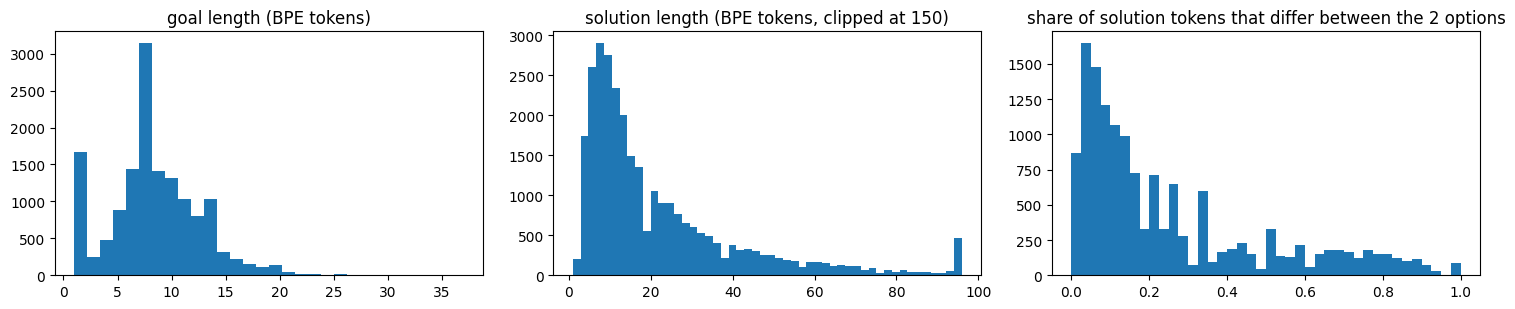

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def split_stats(ds):
    goal_len = [sum(1 for s in it[0][1] if s == 0) - 2 for it in ds.items]
    sol_len = [sum(it[k][3]) for it in ds.items for k in (0, 1)]
    diff_share = [np.mean([t == TAG_DIFF for k in (0, 1) for t, m in zip(it[k][2], it[k][3]) if m] or [0]) for it in ds.items]
    return goal_len, sol_len, diff_share

rows = []
for split in ("train", "val", "test"):
    g, s, d = split_stats(DATA[f"{split}_ds"])
    rows.append({"split": split, "items": len(DATA[f"{split}_ds"]),
                 "label=1 share": np.mean(DATA[f"{split}_ds"].labels) if (split != "test" or FINAL_EVAL) else np.nan,  # test labels only in Step 5
                 "goal BPE len (mean)": np.mean(g), "solution BPE len (mean)": np.mean(s),
                 "solution BPE len (p99)": np.percentile(s, 99),
                 "differing-token share (median)": np.median(d)})
display(pd.DataFrame(rows).round(3))

g, s, d = split_stats(DATA["train_ds"])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(g, bins=30); ax[0].set_title("goal length (BPE tokens)")
ax[1].hist(np.clip(s, 0, 150), bins=50); ax[1].set_title("solution length (BPE tokens, clipped at 150)")
ax[2].hist(d, bins=40); ax[2].set_title("share of solution tokens that differ between the 2 options")
plt.tight_layout(); plt.show()

**What the statistics imply for the design.**
* Labels are balanced, so **accuracy** is an unbiased metric and chance level is 50 %.
* In the median item only a small fraction of solution tokens differ between the two options (right histogram): the answer depends on a few words (*paper strips* vs *jeans material*, *weld* vs *nail*) placed inside otherwise identical text. A model that encodes each option independently must discover this small signal on its own from only 14.5k training items. DACT therefore (i) marks the differing tokens explicitly, (ii) compares the two options with cross-attention and (iii) biases its pooling towards the differing tokens.
* Solutions are short (p99 of about 100 BPE tokens), so we truncate solutions to 96 and goals to 40 tokens.

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 2.1 DACT: Difference-Aware Contrastive Transformer

```
 goal + sol1 ─┐                                     ┌─ diff-guided attention pooling ─┐
              ├─ shared Transformer encoder ─ h1 ─┐ │                                 ├─ scorer → s1 ┐
 tags(sol1)  ─┘   (token+pos+segment+DIFF-TAG)    ├─┤ contrastive cross-solution attn │              ├─ softmax → P(option)
 goal + sol2 ─┐                                   │ │   h_i attends to h_j, fuse      │              │
              ├─ shared Transformer encoder ─ h2 ─┘ │   [h; c; h−c; h⊙c]              ├─ scorer → s2 ┘
 tags(sol2)  ─┘                                     └─────────────────────────────────┘
 sol_i uni/bigrams ─ hashed lexical weights ─────────────────────────────────────────── + w·φ(sol_i) added to s_i
```

| Component | Standard choice | Our PIQA-specific change | Why |
|---|---|---|---|
| Input embedding | token + position (+ segment) | **+ difference-tag embedding** (goal/special, shared, different) | Tells the encoder from layer 1 where the two options disagree, so it does not have to learn this from 14.5k items |
| Option interaction | options scored independently | **Contrastive cross-solution attention**: each token of option *i* attends to the tokens of option *j* (plus a `[CLS]` sink for "no counterpart"), fused ESIM-style with `[h; c; h−c; h⊙c]` | Physical plausibility is relative ("jar" vs "plate"); the comparison features encode what replaced what |
| Summary vector | `[CLS]` or mean pooling | **Difference-guided additive attention pooling** with a learned bias per tag | Puts the decision on the few decisive tokens while the pooling weights remain interpretable |
| Lexical ("wide") head | none | **Learned weight per hashed solution unigram/bigram** (2^18 buckets, starts at 0, own learning rate 1e-2, weight decay), added to each option's score, trained jointly with the Transformer | Baseline B1 shows that which words appear in a solution is a strong signal; a Transformer trained on 14.5k items uses it only indirectly. Under the pairwise softmax only the *difference* of the two lexical scores matters, so the head learns plausible vs implausible words (cf. wide & deep models, Cheng et al., 2016) |
| Objective | independent binary classification | **Pairwise softmax** over the two option scores (label smoothing 0.1) | Matches the forced-choice task |
| Encoder | post-LN Transformer | Pre-LN, shared across options, GELU, dropout 0.2 | Stable training from scratch; weight sharing makes the model **permutation-equivariant** (swapping options swaps scores, verified below), so it cannot learn a position bias |
| (optional) warm-up | none | Masked-LM warm-up on training-split text only | Compensates for the small labelled set without external data; kept only if it helps on validation |

Every component can be switched off in `Config`, which is how the ablations in Section 3 are run.

In [ ]:
"""DACT: Difference-Aware Contrastive Transformer for PIQA (trained from scratch).

Pipeline for one PIQA item (goal g, solutions s1, s2):
  1. each option is encoded as [CLS] g [SEP] s_i [SEP] by a shared Transformer encoder whose input embedding
     = token + position + segment + DIFFERENCE TAG (shared-with-other-option / unique-to-this-option);
  2. CONTRASTIVE CROSS-SOLUTION ATTENTION lets every token of s_i attend to the tokens of s_j, and fuses
     [h; c; h-c; h*c] so the representation explicitly encodes how this option differs from its rival;
  3. DIFFERENCE-GUIDED ATTENTION POOLING summarises each option with a learned bias towards differing tokens;
  4. a shared scorer produces one logit per option; the two logits compete in a softmax.
The same weights process both options, so the model is permutation-equivariant in the option order.
"""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    """Multi-head scaled dot-product attention.

    Uses the fused SDPA kernel for speed during training, and an explicit implementation when the attention
    weights are requested for visualisation.
    """

    def __init__(self, d_model, n_heads, attn_dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.p = attn_dropout

    def forward(self, x, kv, key_mask, return_attn=False):
        B, Lq, D = x.shape
        Lk = kv.size(1)
        q = self.q(x).view(B, Lq, self.h, self.dh).transpose(1, 2)
        k = self.k(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        v = self.v(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        mask = key_mask[:, None, None, :]          # True = may attend
        p = self.p if self.training else 0.0
        attn = None
        if return_attn:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
            scores = scores.masked_fill(~mask, float("-inf"))
            attn = torch.nan_to_num(scores.float().softmax(-1)).to(q.dtype)
            out = F.dropout(attn, p, self.training) @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask, dropout_p=p)
        return self.o(out.transpose(1, 2).reshape(B, Lq, D)), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer encoder block (more stable than post-LN when training from scratch)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.attn_dropout)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Dropout(cfg.dropout),
                                nn.Linear(cfg.d_ff, cfg.d_model))
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, key_mask, return_attn=False):
        a, w = self.attn(self.ln1(x), self.ln1(x), key_mask, return_attn)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, w


class ContrastiveCrossSolution(nn.Module):
    """Each option's tokens attend to the rival option's solution tokens; ESIM-style comparison fusion."""

    def __init__(self, cfg: Config):
        super().__init__()
        d = cfg.d_model
        self.ln = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, cfg.n_heads, cfg.attn_dropout)
        self.fuse = nn.Sequential(nn.Linear(4 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, d))
        self.out_ln = nn.LayerNorm(d)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, h_self, h_other, other_key_mask, return_attn=False):
        q, kv = self.ln(h_self), self.ln(h_other)
        c, w = self.attn(q, kv, other_key_mask, return_attn)
        m = self.fuse(torch.cat([q, c, q - c, q * c], dim=-1))
        return self.out_ln(h_self + self.drop(m)), w


class AttentionPooling(nn.Module):
    """Additive attention pooling over solution tokens.

    mode="diff_attn": score_t = v^T tanh(W h_t) + b[tag_t]  (learned bias per difference tag)
    mode="attn":      same without the tag bias
    mode="mean":      uniform average (ablation)
    """

    def __init__(self, d_model, mode, diff_bias_init=1.0):
        super().__init__()
        self.mode = mode
        self.proj = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, 1, bias=False)
        self.tag_bias = nn.Parameter(torch.tensor([0.0, 0.0, diff_bias_init]))  # other, shared, diff

    def forward(self, h, mask, tags):
        mask = mask.clone()
        mask[~mask.any(-1), 0] = True  # empty solution -> fall back to [CLS]
        if self.mode == "mean":
            w = mask.float() / mask.float().sum(-1, keepdim=True)
        else:
            s = self.v(torch.tanh(self.proj(h))).squeeze(-1).float()
            if self.mode == "diff_attn":
                s = s + self.tag_bias[tags]
            w = s.masked_fill(~mask, float("-inf")).softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return pooled, w


class DACT(nn.Module):
    def __init__(self, cfg: Config, vocab_size):
        super().__init__()
        self.cfg = cfg
        d = cfg.d_model
        self.tok = nn.Embedding(vocab_size, d, padding_idx=PAD)
        self.pos = nn.Embedding(cfg.max_len, d)
        self.seg = nn.Embedding(2, d)
        self.tag = nn.Embedding(3, d) if cfg.use_diff_tags else None
        self.emb_ln = nn.LayerNorm(d)
        self.emb_drop = nn.Dropout(cfg.dropout)
        self.layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.n_layers)])
        self.final_ln = nn.LayerNorm(d)
        self.cross = ContrastiveCrossSolution(cfg) if cfg.use_cross_solution else None
        self.pool = AttentionPooling(d, cfg.pool_mode, cfg.tag_bias_init)
        self.scorer = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, 1))
        # masked-LM head (only used for the optional in-domain warm-up), tied to the token embedding
        self.mlm_transform = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.LayerNorm(d))
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))
        self.apply(self._init)
        # lexical ("wide") head: one learned weight per hashed solution unigram/bigram, starting at zero. A plain
        # parameter (not an nn.Embedding) so that AdamW weight decay regularises it like a logistic regression.
        self.lex_w = nn.Parameter(torch.zeros(cfg.lex_buckets, 1)) if cfg.use_lexical else None

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding) and m.padding_idx is not None:
                with torch.no_grad():
                    m.weight[m.padding_idx].zero_()

    def encode(self, ids, seg, tags, attn_mask, return_attn=False):
        """ids/seg/tags/attn_mask: [N, L] -> hidden states [N, L, d] and per-layer self-attention."""
        L = ids.size(1)
        pos = torch.arange(L, device=ids.device)[None]
        x = self.tok(ids) + self.pos(pos) + self.seg(seg)
        if self.tag is not None:
            x = x + self.tag(tags)
        x = self.emb_drop(self.emb_ln(x))
        attns = []
        for layer in self.layers:
            x, w = layer(x, attn_mask, return_attn)
            attns.append(w)
        return self.final_ln(x), attns

    def forward(self, batch, return_attn=False):
        ids, seg, tags = batch["input_ids"], batch["segment"], batch["tags"]
        attn_mask, sol_mask = batch["attn_mask"], batch["sol_mask"]
        B, _, L = ids.shape
        N = B * 2
        h, self_attn = self.encode(ids.view(N, L), seg.view(N, L), tags.view(N, L), attn_mask.view(N, L),
                                   return_attn)
        h = h.view(B, 2, L, -1)
        out = {}
        if self.cross is not None:
            # keys = the rival's solution tokens plus its [CLS] as a "no match" sink
            key_mask = sol_mask.clone()
            key_mask[:, :, 0] = True
            h1, w12 = self.cross(h[:, 0], h[:, 1], key_mask[:, 1], return_attn)
            h2, w21 = self.cross(h[:, 1], h[:, 0], key_mask[:, 0], return_attn)
            h = torch.stack([h1, h2], dim=1)
            out["cross_attn"] = (w12, w21)
        hf = h.reshape(N, L, -1)
        pooled, pool_w = self.pool(hf, sol_mask.view(N, L), tags.view(N, L))
        feats = torch.cat([pooled, hf[:, 0]], dim=-1)            # pooled solution summary + [CLS]
        logits = self.scorer(feats).view(B, 2).float()
        if self.lex_w is not None:
            # under the pairwise softmax only the difference of the two lexical scores matters, so shared n-grams
            # cancel and the head learns which words make a solution more plausible (cf. baseline B1)
            out["lexical"] = self.lexical_score(ids.view(N, L), sol_mask.view(N, L)).view(B, 2)
            logits = logits + out["lexical"]
        out["logits"] = logits
        out["pool"] = pool_w.view(B, 2, L)
        if return_attn:
            out["self_attn"] = [w.view(B, 2, *w.shape[1:]) for w in self_attn]
        return out

    def lexical_score(self, ids, sol_mask):
        """Sum of learned weights of the hashed BPE unigrams and bigrams of each solution: [N, L] -> [N]."""
        H = self.lex_w.size(0) - 1                               # bucket 0 = padding, always weight 0
        uni = torch.where(sol_mask, 1 + (ids * 40503) % H, 0)
        pair = sol_mask[:, :-1] & sol_mask[:, 1:]
        bi = torch.where(pair, 1 + ((ids[:, :-1] * 8191 + ids[:, 1:]) * 40503 + 7919) % H, 0)
        w = F.embedding(torch.cat([uni, bi], dim=1), self.lex_w, padding_idx=0)
        return w.float().sum((1, 2))

    def mlm_logits(self, ids, seg, tags, attn_mask, selected=None):
        h, _ = self.encode(ids, seg, tags, attn_mask)
        if selected is not None:
            # The pointwise MLM head need only run at supervised positions. The encoder is unchanged.
            h = h[selected]
        return self.mlm_transform(h) @ self.tok.weight.T + self.mlm_bias


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 2.2 Baselines
| ID | Baseline | Trained from scratch? | Role |
|---|---|---|---|
| B0 | Majority class | n/a | chance level |
| B1 | TF-IDF (1-2-grams) of *sol2 − sol1* + logistic regression (C tuned on validation) | yes | How far do shallow lexical cues get? |
| B2 | 2-layer BiLSTM + additive attention, same BPE tokenizer | yes | Same budget, recurrent instead of our Transformer design |
| B3 | `roberta-base` fine-tuned with a multiple-choice head | no (pretrained) | Reference for pretrained encoders |
| B4 | `Qwen2.5-1.5B` zero-shot, length-normalised log-likelihood | no (open LLM) | Reference for LLM knowledge without any training |

In [ ]:
"""Baselines. Every number reported for these is produced by running this code (no numbers copied from papers).

B0  majority class
B1  TF-IDF of solution text + logistic regression (tests shallow lexical cues)
B2  BiLSTM + additive attention, trained from scratch with the same tokenizer (non-Transformer comparison)
B3  fine-tuned pretrained encoder (RoBERTa) with a multiple-choice head
B4  zero-shot open LLM (Qwen2.5), length-normalised log-likelihood of each solution
"""
import copy
import time
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import vstack


# ---------------------------------------------------------------- B0
def majority_baseline(train_rows, rows):
    majority = int(np.mean([r["label"] for r in train_rows]) >= 0.5)
    return np.full(len(rows), majority)


# ---------------------------------------------------------------- B1
def tfidf_lr_baseline(train_rows, val_rows, test_rows=None, Cs=(0.03, 0.1, 0.3, 1.0, 3.0, 10.0)):
    """Feature vector = tfidf(sol2) - tfidf(sol1); trained on both option orders; C picked on validation."""
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True)
    vec.fit([r[k] for r in train_rows for k in ("goal", "sol1", "sol2")])

    def feats(rows):
        return vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])

    Xtr = feats(train_rows)
    ytr = np.array([r["label"] for r in train_rows])
    X_aug, y_aug = vstack([Xtr, -Xtr]), np.concatenate([ytr, 1 - ytr])
    Xva, yva = feats(val_rows), np.array([r["label"] for r in val_rows])
    best = None
    for C in Cs:
        clf = LogisticRegression(C=C, max_iter=2000).fit(X_aug, y_aug)
        acc = float((clf.predict(Xva) == yva).mean())
        if best is None or acc > best[0]:
            best = (acc, C, clf)
    _, C, clf = best
    result = {"C": C, "val_pred": clf.predict(Xva), "vectorizer": vec, "classifier": clf}
    if test_rows is not None:
        result["test_pred"] = clf.predict(feats(test_rows))
    return result


def tfidf_lr_predict(fitted, rows):
    vec = fitted["vectorizer"]
    x = vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])
    return fitted["classifier"].predict(x)


# ---------------------------------------------------------------- B2
class BiLSTMAttention(nn.Module):
    """Each option ([CLS] goal [SEP] sol [SEP]) -> BiLSTM -> additive attention pooling -> score."""

    def __init__(self, cfg: Config, vocab_size, hidden=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD)
        self.lstm = nn.LSTM(cfg.d_model, hidden, num_layers=2, batch_first=True, bidirectional=True,
                            dropout=cfg.dropout)
        self.att_w = nn.Linear(2 * hidden, 2 * hidden)
        self.att_v = nn.Linear(2 * hidden, 1, bias=False)
        self.drop = nn.Dropout(cfg.dropout)
        self.scorer = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.GELU(), nn.Dropout(cfg.dropout),
                                    nn.Linear(hidden, 1))

    def forward(self, batch, return_attn=False):
        ids, mask = batch["input_ids"], batch["attn_mask"]
        B, _, L = ids.shape
        ids, mask = ids.view(B * 2, L), mask.view(B * 2, L)
        lengths = mask.sum(-1).cpu()
        x = self.drop(self.emb(ids))
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h, batch_first=True, total_length=L)
        s = self.att_v(torch.tanh(self.att_w(h))).squeeze(-1).float().masked_fill(~mask, float("-inf"))
        w = s.softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return {"logits": self.scorer(self.drop(pooled)).view(B, 2).float(), "pool": w.view(B, 2, L)}


# ---------------------------------------------------------------- B3
def finetune_pretrained(model_name, train_rows, val_rows, test_rows, device, out_dir, epochs=4, lr=1e-5,
                        batch_size=16, max_len=128, seed=42, verbose=True, revision=None):
    """Fine-tunes a pretrained encoder with a multiple-choice head; model selection on validation only."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer, get_linear_schedule_with_warmup

    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name, revision=revision)
    model = AutoModelForMultipleChoice.from_pretrained(model_name, revision=revision).to(device)
    logger = JsonlLogger(f"{out_dir}/logs/B3_{model_name.split('/')[-1]}_seed{seed}.jsonl")
    if os.path.exists(logger.path):
        raise FileExistsError(logger.path)
    logger.log(event="start", model=model_name, requested_revision=revision,
               resolved_revision=getattr(model.config, "_commit_hash", None), seed=seed,
               epochs=epochs, lr=lr, batch_size=batch_size, max_len=max_len,
               n_params=sum(p.numel() for p in model.parameters()), environment=environment_info(device))

    def encode(rows):
        goals = [r["goal"] for r in rows for _ in range(2)]
        sols = [r[k] for r in rows for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        enc = {k: v.view(len(rows), 2, -1) for k, v in enc.items()}
        return enc, torch.tensor([r["label"] for r in rows])

    def batches(enc, y, shuffle):
        order = torch.randperm(len(y)) if shuffle else torch.arange(len(y))
        for i in range(0, len(y), batch_size):
            idx = order[i:i + batch_size]
            yield {k: v[idx].to(device) for k, v in enc.items()}, y[idx].to(device)

    @torch.no_grad()
    def predict(enc, y):
        model.eval()
        preds = []
        for xb, _ in batches(enc, y, False):
            with autocast_ctx(device):
                preds.append(model(**xb).logits.argmax(-1).cpu())
        return torch.cat(preds).numpy()

    tr, ytr = encode(train_rows)
    va, yva = encode(val_rows)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * ((len(ytr) + batch_size - 1) // batch_size)
    sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    best_acc, best_state = -1.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for xb, yb in batches(tr, ytr, True):
            with autocast_ctx(device):
                loss = F.cross_entropy(model(**xb).logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        val_acc = float((predict(va, yva) == yva.numpy()).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=float(np.mean(losses)), val_acc=val_acc,
                         seconds=round(time.time() - t0, 1))
        if verbose:
            print(f"[B3 {model_name}] ep {epoch} loss {rec['train_loss']:.4f} val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
    model.load_state_dict(best_state)
    checkpoint = f"{out_dir}/checkpoints/B3_{model_name.split('/')[-1]}_seed{seed}"
    model.save_pretrained(checkpoint)
    tok.save_pretrained(checkpoint)
    out = {"val_pred": predict(va, yva), "best_val_acc": best_acc, "checkpoint": checkpoint,
           "max_len": max_len, "batch_size": batch_size}
    if test_rows is not None:
        te, yte = encode(test_rows)
        out["test_pred"] = predict(te, yte)
    logger.log(event="end", best_val_acc=best_acc)
    del model
    return out


@torch.no_grad()
def pretrained_predict(fitted, rows, device):
    """Separate final evaluation of the locally saved validation-selected checkpoint."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(fitted["checkpoint"])
    model = AutoModelForMultipleChoice.from_pretrained(fitted["checkpoint"]).to(device).eval()
    predictions = []
    for start in range(0, len(rows), fitted["batch_size"]):
        chunk = rows[start:start + fitted["batch_size"]]
        goals = [r["goal"] for r in chunk for _ in range(2)]
        sols = [r[k] for r in chunk for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=fitted["max_len"], padding="max_length", return_tensors="pt")
        enc = {k:v.view(len(chunk),2,-1).to(device) for k,v in enc.items()}
        with autocast_ctx(device):
            predictions.append(model(**enc).logits.argmax(-1).cpu())
    return torch.cat(predictions).numpy()


# ---------------------------------------------------------------- B4
@torch.no_grad()
def llm_zero_shot(model_name, rows, device, batch_size=32, verbose=True, revision=None, out_dir=None):
    """Chooses the solution with the higher mean token log-probability given a goal prompt (no training)."""
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tok = AutoTokenizer.from_pretrained(model_name, revision=revision)
    dtype = amp_dtype(device) or torch.float32
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype, revision=revision).to(device).eval()
    if out_dir is not None:
        JsonlLogger(f"{out_dir}/logs/B4_zero_shot.jsonl").log(event="inference", model=model_name,
            requested_revision=revision, resolved_revision=getattr(model.config, "_commit_hash", None),
            n_items=len(rows), batch_size=batch_size, continuation_limit=128,
            environment=environment_info(device))
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id

    seqs = []  # (input ids, number of continuation tokens)
    for r in rows:
        prompt = tok(f"Goal: {r['goal']}\nSolution:", add_special_tokens=True).input_ids
        for k in ("sol1", "sol2"):
            cont = tok(" " + r[k], add_special_tokens=False).input_ids[:128]
            seqs.append((prompt + cont, len(cont)))
    scores = []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i + batch_size]
        L = max(len(s) for s, _ in chunk)
        ids = torch.full((len(chunk), L), pad_id, dtype=torch.long)
        cont_mask = torch.zeros((len(chunk), L), dtype=torch.bool)
        attn = torch.zeros((len(chunk), L), dtype=torch.long)
        for j, (s, n) in enumerate(chunk):
            ids[j, :len(s)] = torch.tensor(s)
            attn[j, :len(s)] = 1
            cont_mask[j, len(s) - n:len(s)] = True
        ids, attn, cont_mask = ids.to(device), attn.to(device), cont_mask.to(device)
        logp = model(input_ids=ids, attention_mask=attn).logits.float().log_softmax(-1)
        tok_lp = logp[:, :-1].gather(-1, ids[:, 1:, None]).squeeze(-1)
        m = cont_mask[:, 1:].float()
        scores.append(((tok_lp * m).sum(-1) / m.sum(-1).clamp(min=1)).cpu())
        if verbose and (i // batch_size) % 50 == 0:
            print(f"[B4 {model_name}] {i}/{len(seqs)}")
    scores = torch.cat(scores).view(-1, 2)
    del model
    return scores.argmax(-1).numpy()

## 2.3 Training utilities
AdamW (β₂ = 0.98, no decay on biases/LayerNorm/embeddings), linear warm-up + cosine decay, gradient clipping, bf16 autocast on GPU, early stopping on **validation** accuracy, and a JSON-lines log for every run.

In [ ]:
"""Training loops (QA fine-tuning, optional in-domain MLM warm-up) with mixed precision and JSONL logging."""
import math
import os
import time
import json
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


N_SPECIAL = 5  # ids < 5 are special tokens and are never masked


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def autocast_ctx(device, enabled=True):
    dtype = amp_dtype(device) if enabled else None
    return torch.autocast("cuda", dtype=dtype) if dtype is not None else nullcontext()


def make_optimizer(model, lr, weight_decay, lex_lr=None):
    """No weight decay on biases, LayerNorm and embedding tables.

    The lexical head (if any) gets its own learning rate: a sparse linear model needs far larger steps than the
    Transformer to move away from zero within the few epochs before early stopping.
    """
    emb = {id(m.weight) for m in model.modules() if isinstance(m, torch.nn.Embedding)}
    lex = getattr(model, "lex_w", None)
    params = [p for p in model.parameters() if p.requires_grad and p is not lex]
    decay = [p for p in params if p.ndim >= 2 and id(p) not in emb]
    no_decay = [p for p in params if p.ndim < 2 or id(p) in emb]
    groups = [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}]
    if lex is not None:
        groups.append({"params": [lex], "weight_decay": weight_decay, "lr": lex_lr or lr})
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.98))


def warmup_cosine(optimizer, total_steps, warmup_ratio):
    warmup = max(1, int(total_steps * warmup_ratio))

    def f(step):
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)


def qa_loss(logits, labels, cfg: Config):
    if cfg.objective == "pairwise":
        return F.cross_entropy(logits, labels, label_smoothing=cfg.label_smoothing)
    target = F.one_hot(labels, 2).float() * (1 - cfg.label_smoothing) + 0.5 * cfg.label_smoothing
    return F.binary_cross_entropy_with_logits(logits, target)


@torch.no_grad()
def predict(model, loader, device, cfg=None):
    """Returns probabilities for option 2 (label 1), predictions and gold labels, ordered by dataset index."""
    model.eval()
    logits, labels, index = [], [], []
    for batch in loader:
        batch = to_device(batch, device)
        with autocast_ctx(device, cfg.amp if cfg is not None else True):
            out = model(batch)
        logits.append(out["logits"].float().cpu())
        labels.append(batch["labels"].cpu())
        index.append(batch["index"].cpu())
    logits, labels, index = torch.cat(logits), torch.cat(labels), torch.cat(index)
    order = index.argsort()
    logits, labels = logits[order], labels[order]
    result = {"prob": logits.softmax(-1)[:, 1].numpy(), "pred": logits.argmax(-1).numpy(),
              "label": labels.numpy()}
    if cfg is not None:
        result["loss"] = float(qa_loss(logits, labels, cfg))
    return result


def train_qa(model, train_loader, val_loader, cfg: Config, device, run_name, verbose=True):
    """Trains with early stopping on validation accuracy; restores and returns the best checkpoint."""
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}.jsonl"))
    ckpt = os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt")
    if os.path.exists(ckpt) or os.path.exists(logger.path):
        raise FileExistsError(f"Run {run_name} already exists. Choose a fresh out_dir or run name; evidence is never overwritten.")
    os.makedirs(os.path.dirname(ckpt), exist_ok=True)
    model.to(device)
    opt = make_optimizer(model, cfg.lr, cfg.weight_decay, cfg.lex_lr)
    sched = warmup_cosine(opt, cfg.epochs * len(train_loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and amp_dtype(device) == torch.float16)
    logger.log(event="start", run=run_name, config=cfg.to_dict(),
               seed=cfg.run_seed, split_seed=cfg.seed, environment=environment_info(device),
               split_sizes={"train": len(train_loader.dataset), "val": len(val_loader.dataset)},
               checkpoint=ckpt, n_params=sum(p.numel() for p in model.parameters()))
    best_acc, best_epoch, bad = -1.0, -1, 0
    history = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0, tot_loss, tot_correct, n = time.time(), 0.0, 0, 0
        for batch in train_loader:
            batch = to_device(batch, device)
            with autocast_ctx(device, cfg.amp):
                out = model(batch)
            loss = qa_loss(out["logits"], batch["labels"], cfg)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Nonfinite QA loss in {run_name}, epoch {epoch}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            bs = batch["labels"].size(0)
            tot_loss += loss.item() * bs
            tot_correct += (out["logits"].argmax(-1) == batch["labels"]).sum().item()
            n += bs
        val = predict(model, val_loader, device, cfg)
        val_acc = float((val["pred"] == val["label"]).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=tot_loss / n, train_acc=tot_correct / n,
                         val_acc=val_acc, val_loss=val["loss"], lr=sched.get_last_lr()[0], seconds=round(time.time() - t0, 2))
        history.append(rec)
        if verbose:
            print(f"[{run_name}] ep {epoch:02d} loss {rec['train_loss']:.4f} train_acc {rec['train_acc']:.4f} "
                  f"val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_epoch, bad = val_acc, epoch, 0
            torch.save(model.state_dict(), ckpt)
            with open(ckpt + ".json", "w", encoding="utf-8") as stream:
                json.dump({"run": run_name, "seed": cfg.run_seed, "config": cfg.to_dict(),
                           "best_val_acc": best_acc, "best_epoch": best_epoch,
                           "selection": "maximum validation accuracy; first epoch wins ties",
                           "environment": environment_info(device)}, stream, indent=2)
        else:
            bad += 1
            if bad >= cfg.patience:
                break
    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    logger.log(event="end", best_val_acc=best_acc, best_epoch=best_epoch)
    if verbose:
        print(f"[{run_name}] best val_acc {best_acc:.4f} at epoch {best_epoch}")
    return model, history


# ----------------------------------------------------------------------------------------------
# In-domain masked-LM warm-up (training split text only; no external data)
# ----------------------------------------------------------------------------------------------
def _mlm_collate(seqs, vocab_size, mask_prob):
    L = max(len(s[0]) for s in seqs)
    ids = torch.full((len(seqs), L), PAD, dtype=torch.long)
    seg = torch.zeros_like(ids)
    tags = torch.zeros_like(ids)
    for i, (a, b, c, _) in enumerate(seqs):
        ids[i, :len(a)], seg[i, :len(b)], tags[i, :len(c)] = torch.tensor(a), torch.tensor(b), torch.tensor(c)
    labels = ids.clone()
    candidates = ids >= N_SPECIAL
    chosen = (torch.rand(ids.shape) < mask_prob) & candidates
    labels[~chosen] = -100
    r = torch.rand(ids.shape)
    inputs = ids.clone()
    inputs[chosen & (r < 0.8)] = MASK
    rand_pos = chosen & (r >= 0.8) & (r < 0.9)
    inputs[rand_pos] = torch.randint(N_SPECIAL, vocab_size, (int(rand_pos.sum()),))
    return {"input_ids": inputs, "segment": seg, "tags": tags, "attn_mask": ids != PAD, "labels": labels}


def mlm_warmup(model, train_ds, cfg: Config, device, vocab_size, run_name, verbose=True):
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}_mlm.jsonl"))
    if os.path.exists(logger.path):
        raise FileExistsError(f"MLM evidence already exists: {logger.path}")
    logger.log(event="start", run=run_name, seed=cfg.run_seed, config=cfg.to_dict(), environment=environment_info(device))
    seqs = [seq for item in train_ds.items for seq in item]
    loader = DataLoader(seqs, batch_size=cfg.batch_size * 2, shuffle=True,
                        collate_fn=lambda b: _mlm_collate(b, vocab_size, cfg.mlm_prob))
    model.to(device)
    opt = make_optimizer(model, cfg.mlm_lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.mlm_epochs * len(loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and amp_dtype(device) == torch.float16)
    for epoch in range(1, cfg.mlm_epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for batch in loader:
            batch = to_device(batch, device)
            selected = batch["labels"] != -100
            if not selected.any():
                continue  # no supervised tokens: mean CE would be NaN
            with autocast_ctx(device, cfg.amp):
                logits = model.mlm_logits(batch["input_ids"], batch["segment"], batch["tags"], batch["attn_mask"], selected)
            loss = F.cross_entropy(logits.float(), batch["labels"][selected])
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Nonfinite MLM loss in {run_name}, epoch {epoch}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        rec = logger.log(event="mlm_epoch", epoch=epoch, loss=float(np.mean(losses)) if losses else None,
                         seconds=round(time.time() - t0, 2))
        if verbose:
            print(f"[{run_name} MLM] ep {epoch:02d} loss {rec['loss']} ({rec['seconds']}s)")
    return model

In [ ]:
"""Evaluation metrics: accuracy, bootstrap confidence intervals, McNemar's exact test, seed aggregation."""
import math
import json
import os

import numpy as np


def save_predictions(path, rows, prediction, run, split):
    """Persist only executed predictions; probabilities are omitted if unavailable (e.g. B0)."""
    if len(rows) != len(prediction["pred"]):
        raise ValueError("Prediction count differs from dataset size")
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "x", encoding="utf-8") as stream:
        for i, (row, pred) in enumerate(zip(rows, prediction["pred"])):
            rec = {"run": run, "split": split, "index": i, "goal": row["goal"],
                   "candidate_1": row["sol1"], "candidate_2": row["sol2"],
                   "gold_label": row["label"], "predicted_label": int(pred),
                   "correct": int(pred) == row["label"]}
            if "prob" in prediction:
                p = float(prediction["prob"][i])
                rec.update(probability_candidate_1=1-p, probability_candidate_2=p)
            stream.write(json.dumps(rec, ensure_ascii=False) + "\n")


def holm_adjust(pvalues):
    """Holm family-wise correction; call on an explicitly declared comparison family."""
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    adjusted[order] = np.minimum(1, np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]))
    return adjusted


def accuracy(pred, label):
    return float((np.asarray(pred) == np.asarray(label)).mean())


def bootstrap_ci(pred, label, n_boot=2000, alpha=0.05, seed=0):
    """Percentile bootstrap CI for accuracy (resampling test items)."""
    correct = (np.asarray(pred) == np.asarray(label)).astype(float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(correct), size=(n_boot, len(correct)))
    accs = correct[idx].mean(1)
    return float(np.quantile(accs, alpha / 2)), float(np.quantile(accs, 1 - alpha / 2))


def mcnemar_exact(pred_a, pred_b, label):
    """Exact two-sided McNemar test on the discordant pairs (binomial with p=0.5).

    b = items A gets right and B gets wrong, c = the reverse. Returns (b, c, p_value).
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return b, c, min(1.0, 2 * p)


def error_overlap(pred_a, pred_b, label):
    """How two models' errors overlap: shares of items both / only A / only B / neither get right.

    `oracle` is the accuracy if we always picked whichever model is right, an upper bound on what combining
    them could achieve; a large gap to both models means they have learned different cues.
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    return {"both correct": float((ca & cb).mean()), "only A": float((ca & ~cb).mean()),
            "only B": float((~ca & cb).mean()), "both wrong": float((~ca & ~cb).mean()),
            "agreement": float((np.asarray(pred_a) == np.asarray(pred_b)).mean()),
            "oracle": float((ca | cb).mean())}


def summarise_seeds(accs):
    accs = np.asarray(accs, dtype=float)
    return {"mean": float(accs.mean()), "std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
            "runs": [float(a) for a in accs]}

In [ ]:
# Sanity checks: parameter count, output shapes, permutation equivariance of DACT
set_seed(0)
_m = DACT(CFG, DATA["vocab_size"]).to(DEVICE).eval()
print(f"DACT parameters: {count_parameters(_m) / 1e6:.2f}M | BiLSTM baseline: {count_parameters(BiLSTMAttention(CFG, DATA['vocab_size'])) / 1e6:.2f}M")
_items = [DATA["train_ds"][i] for i in range(8)]
_b = to_device(collate(_items), DEVICE)
_swapped = to_device(collate([((it[1], it[0]), 1 - y, i) for it, y, i in _items]), DEVICE)
with torch.no_grad():
    _o, _os = _m(_b, return_attn=True), _m(_swapped)
print("logits:", tuple(_o["logits"].shape), "| pooling:", tuple(_o["pool"].shape),
      "| self-attn per layer:", tuple(_o["self_attn"][0].shape))
print("swap option order -> scores swap:", torch.allclose(_o["logits"], _os["logits"].flip(-1), atol=1e-4))
del _m

DACT parameters: 6.38M | BiLSTM baseline: 5.07M


logits: (8, 2) | pooling: (8, 2, 46) | self-attn per layer: (8, 2, 4, 46, 46)
swap option order -> scores swap: True


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 3.1 Experimental protocol
* **Metric: accuracy** (official PIQA metric; the labels are balanced and each item has exactly one correct option, so accuracy is also the expected 0/1 forced-choice score). For every from-scratch model, and for the fine-tuned RoBERTa baseline, we report **mean ± std over 3 seeds**. For the test split we also report a **95 % bootstrap CI** and an **exact McNemar test** against DACT, both computed on the seed with the best *validation* accuracy.
* **Selection:** hyper-parameters are chosen on validation (Step 1). The ablations (Step 3) change one component of the selected configuration at a time, with 3 seeds each.
* **Test:** test labels are used only in Step 5, which loads the saved checkpoints and evaluates every model once. The test file is loaded and tokenised at the start, and B1/B3 compute their test predictions in Step 4 (held unseen until Step 5); no selection uses test data. An audit found one test item that also appears in the training file (see `docs/PROJECT_AUDIT.md`); it is disclosed, not removed, so that all runs share the same split.

In [ ]:
"""Experiment orchestration: multi-seed training, validation-only selection, and a separate final test pass."""
import json
import os

import numpy as np
import torch


ARCHS = {"dact": DACT, "bilstm": BiLSTMAttention}


def build_model(arch, cfg, vocab_size):
    return ARCHS[arch](cfg, vocab_size)


def _load_finished(name, cfg, seeds):
    """Returns the saved validation result of `name` if it finished with the same config, seeds and checkpoints."""
    path = os.path.join(cfg.out_dir, "results", f"{name}_val.json")
    if not os.path.isfile(path):
        return None
    with open(path) as f:
        res = json.load(f)
    # run_seed is set per seed inside run_experiment, so it is not part of the experiment's identity
    strip = lambda c: {k: v for k, v in c.items() if k != "run_seed"}  # noqa: E731
    same = strip(res["config"]) == strip(cfg.to_dict()) and [r["seed"] for r in res["runs"]] == list(seeds)
    return res if same and all(os.path.isfile(r["ckpt"]) for r in res["runs"]) else None


def run_experiment(name, cfg, arch, data, device, seeds, verbose=True, resume=True):
    """Trains `arch` with each seed. Only the validation split is touched; checkpoints are kept for the test pass.

    With resume=True an experiment that already finished in this runtime (same config, seeds and checkpoints on
    disk) is loaded instead of retrained, so re-running the notebook after a crash continues where it stopped.
    """
    if resume:
        done = _load_finished(name, cfg, seeds)
        if done is not None:
            if verbose:
                print(f"==> {name}: already finished, loaded (val acc {done['val']['mean']:.4f})")
            return done
    runs = []
    for seed in seeds:
        cfg = cfg.but(run_seed=seed)
        set_seed(seed, cfg.deterministic)
        run_name = f"{name}_seed{seed}"
        model = build_model(arch, cfg, data["vocab_size"])
        if verbose and seed == seeds[0]:
            print(f"{name}: {count_parameters(model) / 1e6:.2f}M trainable parameters")
        if arch == "dact" and cfg.mlm_epochs > 0:
            model = mlm_warmup(model, data["train_ds"], cfg, device, data["vocab_size"], run_name, verbose)
        train_loader = make_loader(data["train_ds"], cfg, True, device)
        val_loader = make_loader(data["val_ds"], cfg, False, device)
        model, history = train_qa(model, train_loader, val_loader, cfg, device, run_name, verbose)
        val = predict(model, val_loader, device, cfg)
        save_predictions(os.path.join(cfg.out_dir, "predictions", f"{run_name}_val.jsonl"),
                         data["val_ds"].rows, val, run_name, "val")
        runs.append({"seed": seed, "ckpt": os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt"),
                     "val_acc": accuracy(val["pred"], val["label"]), "val_loss": val["loss"],
                     "n_params": count_parameters(model), "epochs": len(history)})
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    res = {"name": name, "arch": arch, "config": cfg.to_dict(), "runs": runs,
           "val": summarise_seeds([r["val_acc"] for r in runs])}
    os.makedirs(os.path.join(cfg.out_dir, "results"), exist_ok=True)
    with open(os.path.join(cfg.out_dir, "results", f"{name}_val.json"), "w", encoding="utf-8") as f:
        json.dump(res, f, indent=2)
    if verbose:
        print(f"==> {name}: val acc {res['val']['mean']:.4f} +- {res['val']['std']:.4f}")
    return res


@torch.no_grad()
def test_experiment(res, data, device):
    """FINAL evaluation on the test split: loads every saved checkpoint of an experiment and predicts once."""
    # Guard: in the notebook FINAL_EVAL is False until the final-results step, so test labels cannot be read earlier.
    # (Run as a plain module, e.g. the smoke test below, FINAL_EVAL is undefined and the check is skipped.)
    if not globals().get("FINAL_EVAL", True):
        raise RuntimeError("test_experiment called before the final-results step (FINAL_EVAL is False)")
    cfg = Config(**res["config"])
    test_loader = make_loader(data["test_ds"], cfg, False, device)
    preds, accs = [], []
    for r in res["runs"]:
        model = build_model(res["arch"], cfg, data["vocab_size"]).to(device)
        model.load_state_dict(torch.load(r["ckpt"], map_location=device, weights_only=True))
        out = predict(model, test_loader, device, cfg)
        save_predictions(os.path.join(cfg.out_dir, "predictions", f"{res['name']}_seed{r['seed']}_test.jsonl"),
                         data["test_ds"].rows, out, f"{res['name']}_seed{r['seed']}", "test")
        preds.append(out)
        accs.append(accuracy(out["pred"], out["label"]))
        del model
    # representative run for significance tests / qualitative analysis = best validation seed (not best test)
    best = int(np.argmax([r["val_acc"] for r in res["runs"]]))
    lo, hi = bootstrap_ci(preds[best]["pred"], preds[best]["label"])
    res["test"] = summarise_seeds(accs)
    res["test"]["best_val_seed"] = res["runs"][best]["seed"]
    res["test"]["best_val_seed_acc"] = accs[best]
    res["test"]["ci95"] = [lo, hi]
    res["test_preds"] = preds[best]
    with open(os.path.join(cfg.out_dir, "results", f"{res['name']}_test.json"), "w", encoding="utf-8") as f:
        json.dump({k: v for k, v in res.items() if k != "test_preds"}, f, indent=2)
    return res

In [ ]:
"""Attention visualisation and quantitative attention statistics for DACT."""
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import json
import textwrap
from matplotlib.gridspec import GridSpec


@torch.no_grad()
def attention_for_example(model, row, tok, cfg, device):
    """Runs one PIQA item through DACT and extracts every attention map needed for the plots (head-averaged)."""
    model.eval()
    enc = encode_example(row, tok, cfg)
    batch = to_device(collate([(enc, row["label"], 0)]), device)
    out = model(batch, return_attn=True)
    probs = out["logits"].softmax(-1)[0].cpu().numpy()
    info = {"probs": probs, "pred": int(probs.argmax()), "label": row["label"],
            "goal": row["goal"], "candidate_1": row["sol1"], "candidate_2": row["sol2"],
            "attention_note": "Head-averaged slices; goal slice excludes other keys; cross slice omits CLS sink; rows need not sum to one.",
            "options": []}
    for k in range(2):
        ids, seg, tags, sol = enc[k]
        sol_pos = [i for i, m in enumerate(sol) if m]
        goal_pos = [i for i, s in enumerate(seg) if s == 0][1:-1]  # drop [CLS] and [SEP]
        info["options"].append({
            "tokens": token_strings(tok, ids), "sol_pos": sol_pos, "goal_pos": goal_pos,
            "diff": [tags[i] == TAG_DIFF for i in sol_pos],
            "pool": out["pool"][0, k].float().cpu().numpy()[sol_pos],
            # last encoder layer: attention of solution tokens (queries) over goal tokens (keys)
            "sol2goal": out["self_attn"][-1][0, k].float().mean(0).cpu().numpy()[np.ix_(sol_pos, goal_pos)],
        })
    if "cross_attn" in out:
        w12 = out["cross_attn"][0][0].float().mean(0).cpu().numpy()
        o1, o2 = info["options"]
        info["cross12"] = w12[np.ix_(o1["sol_pos"], o2["sol_pos"])]
    return info


def _label_ticks(ax, tokens, diff, axis):
    set_ticks = ax.set_xticks if axis == "x" else ax.set_yticks
    set_labels = ax.set_xticklabels if axis == "x" else ax.set_yticklabels
    set_ticks(range(len(tokens)))
    labels = set_labels(tokens, rotation=90 if axis == "x" else 0, fontsize=8)
    for lab, d in zip(labels, diff):
        if d:
            lab.set_color("crimson")
            lab.set_fontweight("bold")


def plot_attention_case(model, row, tok, cfg, device, title="", save_path=None):
    """Four panels: pooling weights for each option, sol1->sol2 cross-attention, sol->goal self-attention.

    Tokens that differ between the two options are shown in bold red.
    """
    info = attention_for_example(model, row, tok, cfg, device)
    o1, o2 = info["options"]
    goal_tokens = [o1["tokens"][i] for i in o1["goal_pos"]]
    longest = max(len(o1["sol_pos"]), len(o2["sol_pos"]))
    fig = plt.figure(figsize=(max(15, min(28, longest * .32)), max(10, min(26, longest * .27))))
    gs = GridSpec(3, 2, height_ratios=[0.35, 1, 1], figure=fig, hspace=0.9, wspace=0.3)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[0, k])
        im = ax.imshow(o["pool"][None], aspect="auto", cmap="viridis", vmin=0,
                       vmax=max(float(o1["pool"].max()), float(o2["pool"].max()), 1e-8))
        fig.colorbar(im, ax=ax, fraction=.025)
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "x")
        ax.set_yticks([])
        tag = " (gold)" if info["label"] == k else ""
        ax.set_title(f"Option {k + 1}{tag}: pooling attention, p={info['probs'][k]:.2f}", fontsize=10)
    if "cross12" in info:
        ax = fig.add_subplot(gs[1:, 0])
        im = ax.imshow(info["cross12"], aspect="auto", cmap="magma")
        _label_ticks(ax, [o2["tokens"][i] for i in o2["sol_pos"]], o2["diff"], "x")
        _label_ticks(ax, [o1["tokens"][i] for i in o1["sol_pos"]], o1["diff"], "y")
        ax.set_title("Cross-solution attention (rows: option 1 queries, cols: option 2 keys)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[1 + k, 1])
        im = ax.imshow(o["sol2goal"], aspect="auto", cmap="Blues")
        _label_ticks(ax, goal_tokens, [False] * len(goal_tokens), "x")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "y")
        ax.set_title(f"Option {k + 1}: last-layer attention to goal tokens", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    verdict = "CORRECT" if info["pred"] == info["label"] else "WRONG"
    fig.suptitle(textwrap.fill(f"{title} [{verdict}] Gold: option {info['label']+1}; predicted: option {info['pred']+1}. Goal: {row['goal']}", 130), fontsize=12)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        with open(str(save_path) + ".json", "w", encoding="utf-8") as stream:
            json.dump(info, stream, indent=2, ensure_ascii=False,
                      default=lambda x: x.tolist() if hasattr(x, "tolist") else x)
    plt.show()
    return info


@torch.no_grad()
def diff_attention_mass(model, loader, device):
    """Share of pooling attention that falls on difference-tagged tokens, per item (mean of the two options)."""
    model.eval()
    mass, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        is_diff = (batch["tags"] == TAG_DIFF).float()
        m = (out["pool"].float() * is_diff).sum(-1).mean(-1)  # [B]
        has_diff = is_diff.sum((-1, -2)) > 0
        mass.append(m[has_diff].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[has_diff].cpu())
    return torch.cat(mass).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def diff_attention_controls(model, cfg, vocab_size, loader, device, seed=0):
    """Separates learned from built-in attention on differing tokens (mean pooling mass per condition).

    trained               : the trained model, as used for prediction
    trained, tag bias = 0 : same weights with the tag bias removed -> focus coming from learned token content only
    untrained             : a freshly initialised model -> focus produced by the initial tag bias alone
    """
    no_bias = copy.deepcopy(model)
    no_bias.pool.tag_bias.zero_()
    set_seed(seed)
    untrained = DACT(cfg, vocab_size).to(device)
    conditions = {"trained": model, "trained, tag bias = 0": no_bias, "untrained (initialisation)": untrained}
    out = {name: float(diff_attention_mass(m, loader, device)[0].mean()) for name, m in conditions.items()}
    del no_bias, untrained
    return out


@torch.no_grad()
def pooling_entropy(model, loader, device):
    """Normalised entropy of the pooling weights over each option's solution tokens (1 = uniform, 0 = one token).

    Returns per-item values (mean of the two options) and whether the item was predicted correctly.
    """
    model.eval()
    ent, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        w = out["pool"].float().clamp_min(1e-12)
        n = batch["sol_mask"].sum(-1).float()
        h = -(w * w.log() * batch["sol_mask"]).sum(-1) / n.clamp(min=2).log()
        keep = (n > 1).all(-1)
        ent.append(h.mean(-1)[keep].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[keep].cpu())
    return torch.cat(ent).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def _layer_states(model, batch):
    """Hidden states after the embedding and after every encoder layer, for both options: list of [N, L, d]."""
    ids, seg, tags, mask = (batch[k].flatten(0, 1) for k in ("input_ids", "segment", "tags", "attn_mask"))
    pos = torch.arange(ids.size(1), device=ids.device)[None]
    x = model.tok(ids) + model.pos(pos) + model.seg(seg)
    if model.tag is not None:
        x = x + model.tag(tags)
    x = model.emb_ln(x)
    states = [x]
    for layer in model.layers:
        x, _ = layer(x, mask)
        states.append(x)
    return states


def diff_probe_by_layer(model, train_loader, eval_loader, device, max_tokens=40000, seed=0):
    """Linear probe: can a logistic regression tell differing from shared solution tokens at each layer?

    Trained on solution tokens from `train_loader` and scored (balanced accuracy, 0.5 = chance) on `eval_loader`.
    For a model without tag embeddings this shows whether the encoder works out the difference by itself; for DACT
    it shows whether the injected tag survives through the layers or fades.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import balanced_accuracy_score

    model.eval()

    def collect(loader):
        per_layer, labels, n = [[] for _ in range(len(model.layers) + 1)], [], 0
        for batch in loader:
            batch = to_device(batch, device)
            sol = batch["sol_mask"].flatten(0, 1)
            for store, s in zip(per_layer, _layer_states(model, batch)):
                store.append(s[sol].float().cpu())
            labels.append((batch["tags"].flatten(0, 1) == TAG_DIFF)[sol].cpu())
            n += int(sol.sum())
            if n >= max_tokens:
                break
        return [torch.cat(s).numpy() for s in per_layer], torch.cat(labels).numpy()

    Xtr, ytr = collect(train_loader)
    Xte, yte = collect(eval_loader)
    scores = []
    for layer, (a, b) in enumerate(zip(Xtr, Xte)):
        clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed).fit(a, ytr)
        scores.append({"layer": "embedding" if layer == 0 else f"encoder {layer}",
                       "balanced acc": float(balanced_accuracy_score(yte, clf.predict(b)))})
    return scores


def diff_token_share(loader):
    """Fraction of solution tokens that are difference-tagged, per item (the uniform-attention reference)."""
    shares = []
    for batch in loader:
        is_diff = (batch["tags"] == TAG_DIFF).float()
        sol = batch["sol_mask"].float()
        s = (is_diff.sum(-1) / sol.sum(-1).clamp(min=1)).mean(-1)
        has_diff = is_diff.sum((-1, -2)) > 0
        shares.append(s[has_diff])
    return torch.cat(shares).numpy()


def select_cases(pred, prob, label, k=2):
    """Picks the most confident correct, most confident wrong and most uncertain items."""
    pred, prob, label = map(np.asarray, (pred, prob, label))
    conf = np.abs(prob - 0.5)
    correct = np.where(pred == label)[0]
    wrong = np.where(pred != label)[0]
    return {
        "confident_correct": correct[np.argsort(-conf[correct])][:k].tolist(),
        "confident_wrong": wrong[np.argsort(-conf[wrong])][:k].tolist(),
        "uncertain": np.argsort(conf)[:k].tolist(),
    }

In [ ]:
import pandas as pd
SEEDS = [42] if SMOKE else [42, 43, 44]
EXP = {}        # name -> result dict of from-scratch experiments

### Step 1: hyper-parameter selection (validation only, 1 seed)
A small grid chosen after an initial run showed fast over-fitting (training accuracy far above validation accuracy after a few epochs): model size, dropout, and the in-domain MLM warm-up.

**Lexical head (selected before this grid, validation only).** After the first full run, DACT and TF-IDF + LR were level on validation (59.4 vs 59.2 %). A pilot on the validation split (`tools/pilot_lexical.py`, 3 seeds each, small configuration; the test split was not loaded) compared DACT without the head (59.4 ± 0.8 %) with the head at learning rates 3e-4 (59.5 ± 0.9), 3e-3 (60.5 ± 0.7), **1e-2 (60.9 ± 0.6)** and 3e-2 (60.6 ± 0.3). The head with `lex_lr = 1e-2` was therefore made part of DACT; the grid below and all ablations use it, and *− lexical head* measures its contribution.

In [ ]:
GRID = {
    "base (d=256, L=4, drop=0.2)": CFG,
    "small (d=128, L=2)": CFG.but(d_model=128, d_ff=512, n_layers=2),
    "base, dropout 0.3": CFG.but(dropout=0.3, attn_dropout=0.15),
    "base + MLM warm-up (10 ep)": CFG.but(mlm_epochs=1 if SMOKE else 10),
    "small + MLM warm-up (10 ep)": CFG.but(d_model=128, d_ff=512, n_layers=2, mlm_epochs=1 if SMOKE else 10),
}
grid_res = {k: run_experiment(f"hp{i}", c, "dact", DATA, DEVICE, seeds=[42]) for i, (k, c) in enumerate(GRID.items())}
display(pd.DataFrame([{"config": k, "val acc": r["val"]["mean"], "epochs run": r["runs"][0]["epochs"]}
                      for k, r in grid_res.items()]).round(4))
BEST_HP = max(grid_res, key=lambda k: grid_res[k]["val"]["mean"])
BEST_CFG = GRID[BEST_HP]
print("selected on validation:", BEST_HP)

hp0: 6.38M trainable parameters


[hp0_seed42] ep 01 loss 0.6838 train_acc 0.5622 val_acc 0.5856 (5.19s)


[hp0_seed42] ep 02 loss 0.5821 train_acc 0.7386 val_acc 0.5955 (4.44s)


[hp0_seed42] ep 03 loss 0.4683 train_acc 0.8437 val_acc 0.5962 (4.23s)


[hp0_seed42] ep 04 loss 0.4053 train_acc 0.8908 val_acc 0.5993 (4.42s)


...

[hp4_seed42] ep 10 loss 0.2623 train_acc 0.9760 val_acc 0.5819 (3.07s)


[hp4_seed42] ep 11 loss 0.2549 train_acc 0.9817 val_acc 0.5775 (3.16s)
[hp4_seed42] best val_acc 0.6098 at epoch 5


==> hp4: val acc 0.6098 +- 0.0000


,config,val acc,epochs run
0,"base (d=256, L=4, drop=0.2)",0.6117,11
1,"small (d=128, L=2)",0.6148,11
2,"base, dropout 0.3",0.6073,14
3,base + MLM warm-up (10 ep),0.6092,8
4,small + MLM warm-up (10 ep),0.6098,11


selected on validation: small (d=128, L=2)


### Step 2: main model (selected configuration, 3 seeds)

In [ ]:
EXP["DACT (full)"] = run_experiment("dact_full", BEST_CFG, "dact", DATA, DEVICE, SEEDS)

dact_full: 1.93M trainable parameters


[dact_full_seed42] ep 01 loss 0.6858 train_acc 0.5613 val_acc 0.6030 (3.12s)


[dact_full_seed42] ep 02 loss 0.5843 train_acc 0.7522 val_acc 0.5962 (2.95s)


[dact_full_seed42] ep 03 loss 0.4691 train_acc 0.8449 val_acc 0.6011 (2.95s)


[dact_full_seed42] ep 04 loss 0.4062 train_acc 0.8881 val_acc 0.6061 (2.95s)


...

[dact_full_seed44] ep 07 loss 0.3067 train_acc 0.9520 val_acc 0.5974 (3.03s)


[dact_full_seed44] ep 08 loss 0.2899 train_acc 0.9613 val_acc 0.5968 (3.15s)


[dact_full_seed44] ep 09 loss 0.2751 train_acc 0.9702 val_acc 0.5900 (3.02s)


[dact_full_seed44] ep 10 loss 0.2644 train_acc 0.9752 val_acc 0.5868 (3.06s)
[dact_full_seed44] best val_acc 0.6079 at epoch 4


==> dact_full: val acc 0.6121 +- 0.0036


### Step 3: ablation studies (3 seeds each, one change at a time)
| Ablation | What is removed / replaced | Hypothesis tested |
|---|---|---|
| − difference tags | tag embedding removed | explicit difference marking helps |
| − cross-solution attention | options are no longer compared | comparing the options matters |
| − diff bias in pooling | additive attention pooling without tag bias | steering the pooling towards differing tokens helps |
| mean pooling | uniform average instead of attention pooling | an attention-based summary is better than a uniform one |
| pointwise objective | independent BCE per option instead of pairwise softmax | the forced-choice objective helps |
| vanilla Transformer | no tags, no cross-attention, mean pooling, no lexical head | the combined contribution of our changes |
| − MLM warm-up | (only if the selected config uses it) | in-domain pre-training on training-split text helps |
| − lexical head | no hashed n-gram weights | explicit lexical evidence adds to the neural comparison |
| diff-bias prior 0 | pooling tag bias for differing tokens starts at 0 instead of 1 | the model *learns* to focus on differing tokens, rather than the focus being built in by the initial bias |

In [ ]:
ABLATIONS = {
    "− difference tags": dict(use_diff_tags=False),
    "− cross-solution attention": dict(use_cross_solution=False),
    "− diff bias in pooling": dict(pool_mode="attn"),
    "mean pooling": dict(pool_mode="mean"),
    "pointwise objective": dict(objective="pointwise"),
    "vanilla Transformer": dict(use_diff_tags=False, use_cross_solution=False, pool_mode="mean", use_lexical=False),
    "− lexical head": dict(use_lexical=False),
}
if BEST_CFG.mlm_epochs > 0:
    ABLATIONS["− MLM warm-up"] = dict(mlm_epochs=0)
ABLATIONS["diff-bias prior 0"] = dict(tag_bias_init=0.0)   # added in revision 2
for i, (name, kw) in enumerate(ABLATIONS.items()):
    EXP[name] = run_experiment(f"abl{i}", BEST_CFG.but(**kw), "dact", DATA, DEVICE, SEEDS)

abl0: 1.93M trainable parameters


[abl0_seed42] ep 01 loss 0.6862 train_acc 0.5581 val_acc 0.5732 (3.05s)


[abl0_seed42] ep 02 loss 0.5905 train_acc 0.7708 val_acc 0.5900 (3.31s)


[abl0_seed42] ep 03 loss 0.4766 train_acc 0.8541 val_acc 0.5931 (3.09s)


[abl0_seed42] ep 04 loss 0.4108 train_acc 0.8967 val_acc 0.5906 (3.01s)


...

[abl7_seed44] ep 07 loss 0.3084 train_acc 0.9499 val_acc 0.5937 (3.4s)


[abl7_seed44] ep 08 loss 0.2908 train_acc 0.9617 val_acc 0.5912 (2.95s)


[abl7_seed44] ep 09 loss 0.2765 train_acc 0.9691 val_acc 0.5937 (3.19s)


[abl7_seed44] ep 10 loss 0.2653 train_acc 0.9741 val_acc 0.5856 (3.01s)
[abl7_seed44] best val_acc 0.6185 at epoch 4


==> abl7: val acc 0.6164 +- 0.0031


### Step 4: baselines (validation)

In [ ]:
yva = np.array([r["label"] for r in DATA["val"]])
BASE = {}   # name -> {"val_acc", "val_pred", and later "test_pred"}
BASE["B0 majority"] = {"val_pred": majority_baseline(DATA["train"], DATA["val"])}
b1 = tfidf_lr_baseline(DATA["train"], DATA["val"], DATA["test"])
BASE["B1 TF-IDF + LR"] = {"val_pred": b1["val_pred"], "held_out_test_pred": b1["test_pred"]}
print("B1 selected C on validation:", b1["C"])
EXP["B2 BiLSTM + attention"] = run_experiment("b2_bilstm", CFG.but(lr=1e-3, dropout=0.3), "bilstm", DATA, DEVICE, SEEDS)

B1 selected C on validation: 3.0
b2_bilstm: 5.07M trainable parameters


[b2_bilstm_seed42] ep 01 loss 0.6930 train_acc 0.5005 val_acc 0.5205 (5.7s)


[b2_bilstm_seed42] ep 02 loss 0.6919 train_acc 0.5160 val_acc 0.5242 (5.14s)


[b2_bilstm_seed42] ep 03 loss 0.6856 train_acc 0.5470 val_acc 0.5403 (5.39s)


[b2_bilstm_seed42] ep 04 loss 0.6768 train_acc 0.5722 val_acc 0.5527 (5.14s)


...

[b2_bilstm_seed44] ep 17 loss 0.4698 train_acc 0.8106 val_acc 0.6036 (5.09s)


[b2_bilstm_seed44] ep 18 loss 0.4639 train_acc 0.8130 val_acc 0.6086 (5.31s)


[b2_bilstm_seed44] ep 19 loss 0.4653 train_acc 0.8136 val_acc 0.6048 (5.06s)


[b2_bilstm_seed44] ep 20 loss 0.4648 train_acc 0.8113 val_acc 0.6055 (5.36s)
[b2_bilstm_seed44] best val_acc 0.6086 at epoch 18


==> b2_bilstm: val acc 0.5949 +- 0.0120


In [ ]:
# B3: pretrained encoder fine-tuning, 3 seeds like the from-scratch models. Model selection uses validation only;
# the test predictions are stored unseen for Step 5 (produced here only to avoid keeping 3 x 500 MB checkpoints).
B3_NAME = "FacebookAI/roberta-base"
_tr, _va, _te = (DATA["train"][:64], DATA["val"], DATA["test"]) if SMOKE else (DATA["train"], DATA["val"], DATA["test"])
b3_runs = []
for seed in SEEDS:
    b3 = finetune_pretrained(B3_NAME, _tr, _va, _te, DEVICE, CFG.out_dir, epochs=1 if SMOKE else 4,
                             batch_size=8 if SMOKE else 32, lr=2e-5, seed=seed)
    b3["val_acc"] = accuracy(b3["val_pred"], yva)
    b3_runs.append(b3)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
b3_val = [r["val_acc"] for r in b3_runs]
best_b3 = b3_runs[int(np.argmax(b3_val))]   # representative run = best validation seed, as for DACT
BASE["B3 RoBERTa-base (fine-tuned)"] = {
    "val_pred": best_b3["val_pred"], "held_out_test_pred": best_b3["test_pred"],
    "held_out_test_preds": [r["test_pred"] for r in b3_runs],
    "val_acc": float(np.mean(b3_val)), "val_std": float(np.std(b3_val, ddof=1)) if len(b3_val) > 1 else np.nan}
print("B3 val acc per seed:", dict(zip(SEEDS, np.round(b3_val, 4))))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[B3 FacebookAI/roberta-base] ep 2 loss 0.6719 val_acc 0.6669 (27.3s)


[B3 FacebookAI/roberta-base] ep 3 loss 0.6012 val_acc 0.6898 (27.5s)


[B3 FacebookAI/roberta-base] ep 4 loss 0.5380 val_acc 0.6911 (27.4s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

B3 val acc per seed: {42: np.float64(0.6576), 43: np.float64(0.6911), 44: np.float64(0.6911)}


In [ ]:
# B4: zero-shot open LLM (no training at all)
B4_NAME = "Qwen/Qwen2.5-0.5B" if SMOKE else "Qwen/Qwen2.5-1.5B"
BASE["B4 Qwen2.5-1.5B (zero-shot)"] = {"val_pred": llm_zero_shot(B4_NAME, DATA["val"], DEVICE, verbose=False)}
for k, v in BASE.items():
    v.setdefault("val_acc", accuracy(v["val_pred"], yva))   # B3 already holds its mean over seeds
    print(f"{k:32s} val acc {v['val_acc']:.4f}")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

B0 majority                      val acc 0.5000
B1 TF-IDF + LR                   val acc 0.5924
B3 RoBERTa-base (fine-tuned)     val acc 0.6799
B4 Qwen2.5-1.5B (zero-shot)      val acc 0.7810


## 3.2 Step 5: final test evaluation (the only use of test labels)

In [ ]:
FINAL_EVAL = True   # Step 5: the only point from which test labels are read
yte = np.array([r["label"] for r in DATA["test"]])
print(f"test items: {len(yte)} | label=1 share: {yte.mean():.3f}")
for name, res in EXP.items():
    test_experiment(res, DATA, DEVICE)
BASE["B0 majority"]["test_pred"] = majority_baseline(DATA["train"], DATA["test"])
BASE["B1 TF-IDF + LR"]["test_pred"] = BASE["B1 TF-IDF + LR"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"] = BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_accs"] = [accuracy(p, yte) for p in BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_preds"]]
BASE["B4 Qwen2.5-1.5B (zero-shot)"]["test_pred"] = llm_zero_shot(B4_NAME, DATA["test"], DEVICE, verbose=False)

ref = EXP["DACT (full)"]["test_preds"]["pred"]
def row(name, val_mean, val_std, test_mean, test_std, pred, scratch):
    lo, hi = bootstrap_ci(pred, yte)
    b, c, p = mcnemar_exact(ref, pred, yte)
    return {"model": name, "from scratch": scratch, "val acc": val_mean, "val std": val_std,
            "test acc": test_mean, "test std": test_std, "test 95% CI": f"[{lo:.3f}, {hi:.3f}]",
            "McNemar p vs DACT": p if name != "DACT (full)" else np.nan}

table = []
for name, res in EXP.items():
    table.append(row(name, res["val"]["mean"], res["val"]["std"], res["test"]["mean"], res["test"]["std"],
                     res["test_preds"]["pred"], True))
for name, v in BASE.items():
    accs = v.get("test_accs", [accuracy(v["test_pred"], yte)])
    table.append(row(name, v["val_acc"], v.get("val_std", np.nan), float(np.mean(accs)),
                     float(np.std(accs, ddof=1)) if len(accs) > 1 else np.nan, v["test_pred"],
                     name.startswith(("B0", "B1"))))
RESULTS = pd.DataFrame(table)
# how many training runs each row averages over (B0/B1 are deterministic, B4 is zero-shot: a single run is exact)
N_SEEDS = {name: len(res["runs"]) for name, res in EXP.items()}
N_SEEDS.update({name: len(v.get("test_accs", [None])) for name, v in BASE.items()})
RESULTS.insert(2, "n seeds", RESULTS["model"].map(N_SEEDS))
RESULTS["note"] = RESULTS["n seeds"].map(lambda n: "" if n > 1 else "single run: no seed std")
RESULTS.to_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"), index=False)
pd.set_option("display.width", 200)
display(RESULTS.round(4))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

,model,from scratch,n seeds,val acc,val std,test acc,test std,test 95% CI,McNemar p vs DACT,note
0,DACT (full),True,3,0.6121,0.0036,0.6157,0.0013,"[0.594, 0.636]",NaN,
1,− difference tags,True,3,0.5988,0.0050,0.6063,0.0123,"[0.580, 0.624]",0.1546,
2,− cross-solution attention,True,3,0.6050,0.0072,0.6074,0.0061,"[0.592, 0.636]",1.0000,
3,− diff bias in pooling,True,3,0.6170,0.0028,0.6177,0.0027,"[0.595, 0.639]",0.8345,
4,mean pooling,True,3,0.6108,0.0042,0.6099,0.0033,"[0.591, 0.635]",1.0000,
5,pointwise objective,True,3,0.6050,0.0029,0.6157,0.0008,"[0.592, 0.635]",1.0000,
6,vanilla Transformer,True,3,0.5875,0.0081,0.5921,0.0110,"[0.558, 0.602]",0.0037,
7,− lexical head,True,3,0.5945,0.0091,0.6115,0.0043,"[0.592, 0.635]",1.0000,
8,diff-bias prior 0,True,3,0.6164,0.0031,0.6173,0.0030,"[0.592, 0.637]",1.0000,
9,B2 BiLSTM + attention,True,3,0.5949,0.0120,0.6007,0.0075,"[0.570, 0.615]",0.0999,


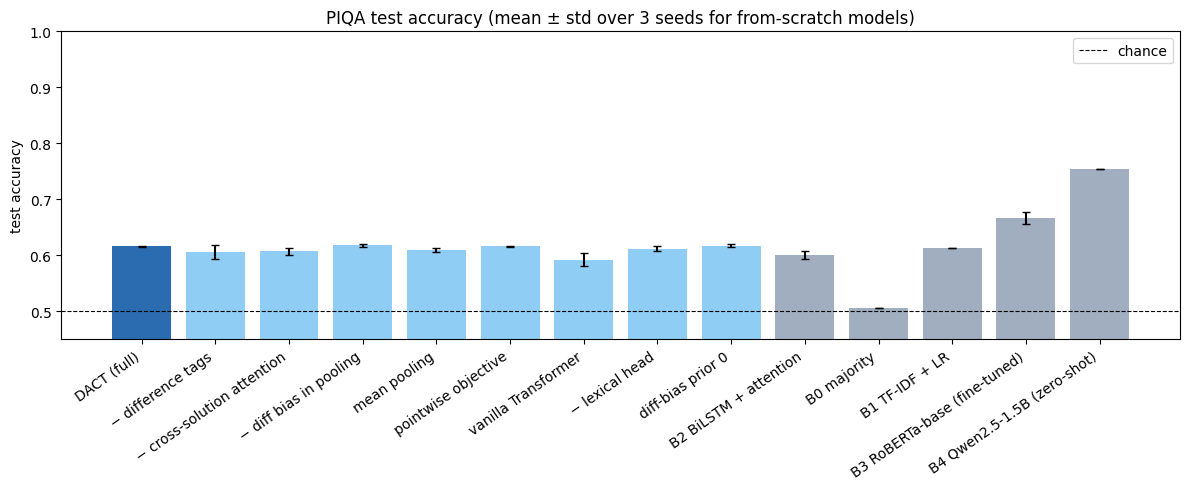

In [ ]:
order = ["DACT (full)"] + list(ABLATIONS) + ["B2 BiLSTM + attention"] + list(BASE)
R = RESULTS.set_index("model").loc[order]
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2b6cb0"] + ["#90cdf4"] * len(ABLATIONS) + ["#a0aec0"] * (1 + len(BASE))
ax.bar(range(len(R)), R["test acc"], yerr=R["test std"].fillna(0), color=colors, capsize=3)
ax.axhline(0.5, ls="--", c="k", lw=0.8, label="chance")
ax.set_xticks(range(len(R))); ax.set_xticklabels(R.index, rotation=35, ha="right")
ax.set_ylabel("test accuracy"); ax.set_ylim(0.45, 1.0); ax.legend()
ax.set_title("PIQA test accuracy (mean ± std over 3 seeds for from-scratch models)")
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "results", "test_accuracy.png"), dpi=120); plt.show()

### Where do DACT and the baselines disagree? (error overlap)
Accuracy alone cannot tell whether DACT and TF-IDF + LR get the *same* items right. For each pair we count the test items both / only one / neither model answer correctly (representative runs, chosen on validation). A high *oracle* accuracy (right if either model is right) compared with both models means they rely on different cues; an oracle close to the better model means one model's knowledge is essentially a subset of the other's.

In [ ]:
PAIRS = {"B1 TF-IDF + LR": BASE["B1 TF-IDF + LR"]["test_pred"],
         "B2 BiLSTM + attention": EXP["B2 BiLSTM + attention"]["test_preds"]["pred"],
         "vanilla Transformer": EXP["vanilla Transformer"]["test_preds"]["pred"],
         "B3 RoBERTa-base (fine-tuned)": BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"]}
OVERLAP = pd.DataFrame({name: error_overlap(ref, pred, yte) for name, pred in PAIRS.items()}).T
OVERLAP.columns = ["both correct", "only DACT", "only other", "both wrong", "agreement", "oracle"]
OVERLAP.to_csv(os.path.join(CFG.out_dir, "results", "error_overlap.csv"))
display(OVERLAP.round(3))

,both correct,only DACT,only other,both wrong,agreement,oracle
B1 TF-IDF + LR,0.503,0.112,0.109,0.276,0.779,0.724
B2 BiLSTM + attention,0.450,0.164,0.142,0.244,0.694,0.756
vanilla Transformer,0.468,0.146,0.111,0.275,0.743,0.725
B3 RoBERTa-base (fine-tuned),0.448,0.166,0.222,0.164,0.612,0.836


In [ ]:
# Items DACT gets right and TF-IDF + LR gets wrong: what does the neural model add beyond word statistics?
only_dact = np.where((ref == yte) & (BASE["B1 TF-IDF + LR"]["test_pred"] != yte))[0]
print(f"{len(only_dact)} test items are solved by DACT but not by TF-IDF + LR; three of them:")
for j in only_dact[:3]:
    r = DATA["test"][j]
    print(f"--- test item {j} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")

205 test items are solved by DACT but not by TF-IDF + LR; three of them:
--- test item 4 | gold = option 1
  goal: ice box
  sol1: will turn into a cooler if you add water to it
  sol2: will turn into a cooler if you add soda to it
--- test item 6 | gold = option 2
  goal: Recycle a spray bottle for a new cleaner.
  sol1: Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty sparrow bottle and allow to dry before using with a new cleaner.
  sol2: Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty spray bottle and allow to dry before using with a new cleaner.
--- test item 20 | gold = option 1
  goal: What alcohol do you pour for a mojito?
  sol1: Fill the glass with ice cubes so it’s half full. Pour in 2 shots of white rum & 1-

In [ ]:
# Every number quoted in the discussion below, in percent, straight from RESULTS (copy from here, never retype).
R = RESULTS.set_index("model")
KEY = (R[["n seeds", "val acc", "val std", "test acc", "test std"]] * [1, 100, 100, 100, 100]).round(1)
KEY["val Δ vs DACT"] = (KEY["val acc"] - KEY.loc["DACT (full)", "val acc"]).round(1)
KEY["test Δ vs DACT"] = (KEY["test acc"] - KEY.loc["DACT (full)", "test acc"]).round(1)
display(KEY)

,n seeds,val acc,val std,test acc,test std,val Δ vs DACT,test Δ vs DACT
model,,,,,,,
DACT (full),3,61.2,0.4,61.6,0.1,0.0,0.0
− difference tags,3,59.9,0.5,60.6,1.2,-1.3,-1.0
− cross-solution attention,3,60.5,0.7,60.7,0.6,-0.7,-0.9
− diff bias in pooling,3,61.7,0.3,61.8,0.3,0.5,0.2
mean pooling,3,61.1,0.4,61.0,0.3,-0.1,-0.6
pointwise objective,3,60.5,0.3,61.6,0.1,-0.7,0.0
vanilla Transformer,3,58.7,0.8,59.2,1.1,-2.5,-2.4
− lexical head,3,59.4,0.9,61.2,0.4,-1.8,-0.4
diff-bias prior 0,3,61.6,0.3,61.7,0.3,0.4,0.1


### Quantitative discussion

> **Validity of the test numbers.** Validation accuracy is the only number that reflects design decisions. The test set was evaluated in several development runs, and the lexical head was introduced after earlier test results had been seen, so test numbers are reported for completeness and comparison, not as a clean held-out estimate. **On test, DACT and TF-IDF + LR are statistically tied** (61.6 vs 61.2 %, McNemar p = 0.88); DACT's advantage is on validation.
>
> **Audit checks (reproduced with `tools/verify_audit_claims.py`, `tools/rescore_without_duplicate.py`; values in `outputs/results/audit_checks.csv` and `rescore_without_duplicate.csv`).** One test item (index 1545) appears twice in our training split; re-scoring the saved test predictions without it changes accuracy by about 0.02 points (DACT 61.57 → 61.55 %, TF-IDF 61.21 → 61.19 %). 102 test items change difference tags when the two options are swapped (0 with the opt-in canonical alignment). The model overfits quickly: training accuracy is 89–92 % against about 61 % on validation at the selected epoch, and 97–98 % by the last epoch.


All numbers below are printed by the key-numbers cell above (percent; mean ± std over 3 seeds where *n seeds* = 3).

**Main comparison.**

| Model | Val | Test |
|---|---|---|
| **DACT (ours, with lexical head)** | **61.2 ± 0.4** | **61.6 ± 0.1** |
| DACT without lexical head (ablation) | 59.4 ± 0.9 | 61.2 ± 0.4 |
| Vanilla Transformer (same budget, no DACT components, no lexical head) | 58.7 ± 0.8 | 59.2 ± 1.1 |
| B2 BiLSTM + attention | 59.5 ± 1.2 | 60.1 ± 0.7 |
| B1 TF-IDF + logistic regression | 59.2 | 61.2 |
| B3 RoBERTa-base, fine-tuned | 68.0 ± 1.9 | 66.7 ± 1.1 |
| B4 Qwen2.5-1.5B, zero-shot | 78.1 | 75.4 |

0. **Selected configuration.** Step 1 selected the *small* model (d = 128, 2 layers; 1.93 M parameters including the 262 k lexical weights) with 61.3 % validation accuracy, ahead of *base* (61.0), the two MLM warm-up variants (60.9, 61.0) and *base, dropout 0.3* (60.9). The spread of the grid (0.4 points) is below one seed std, so size, dropout and warm-up matter little here; the warm-up is not used, so there is no *− MLM* ablation.
1. **DACT is the best from-scratch model on both splits.** It is +2.0 (val) / +0.4 (test) above TF-IDF + LR, +2.5 / +2.4 above the vanilla Transformer and +1.7 / +1.5 above the BiLSTM. On test, the gap to the vanilla Transformer is significant (McNemar p = 0.004), the gap to the BiLSTM is not (p = 0.10). The gap to TF-IDF + LR on test is small and **not significant** (p = 0.88; the 95 % CI of a single model spans about ±2.1 points), so the precise claim is that DACT is at least as good as the strong lexical baseline and above it on both splits, not that it clearly beats it.
2. **The lexical head is what closed the gap to bag-of-words.** In the run without the head, DACT was 1 point *below* TF-IDF on test (60.2 vs 61.2). The head's configuration was selected on validation only (Step 1). *Protocol note:* the decision to explore a lexical component was taken after the test results of the earlier runs had been seen, so the small test gap to TF-IDF should be read as indicative rather than as a clean held-out result (validation already showed the two level, 59.4 vs 59.2 %). Within this run, removing the head costs 1.8 (val) / 0.4 (test) points. The neural part and the lexical part are complementary: the neural model alone and the lexical baseline alone are each about 61 % on test, while their combination inside DACT is the best from-scratch model.
3. **Pretrained knowledge remains the main gap.** All three RoBERTa seeds trained (65.8, 69.1, 69.1 % val; seed 42 learned slowly, and in earlier runs one seed stayed at chance, see Dodge et al., 2020), giving 66.7 % test, 5.1 points above DACT. The zero-shot 1.5 B-parameter LLM is 13.8 points above DACT without any training on PIQA, in line with PIQA testing physical commonsense rather than reading skill.
4. **The result reproduces.** An earlier run of the same model on a free T4 (commit `538cf5b`) gave DACT 61.1 ± 0.8 (val) / 61.6 ± 0.7 (test); this A100 run gives 61.2 ± 0.4 / 61.6 ± 0.1. Individual ablation and baseline numbers moved by up to about 1 point between the two runs (most notably the BiLSTM on test, 58.7 → 60.1), which is the scale of noise to keep in mind below.

**Ablations** (Δ vs full DACT; validation is the split used for decisions):

| Ablation | Val Δ | Test Δ |
|---|---|---|
| − difference tags | −1.3 | −1.0 |
| − lexical head | −1.8 | −0.4 |
| − cross-solution attention | −0.7 | −0.9 |
| pointwise objective | −0.7 | 0.0 |
| mean pooling | −0.1 | −0.6 |
| − diff bias in pooling | +0.5 | +0.2 |
| diff-bias prior 0 | +0.4 | +0.1 |
| **vanilla (tags, cross-attention, attention pooling, lexical head all removed)** | **−2.5** | **−2.4** |

* **Difference tags** (−1.3 / −1.0) and **cross-solution attention** (−0.7 / −0.9) help on both splits. The **lexical head** helps clearly on validation (−1.8) and slightly on test (−0.4); the **pairwise objective** helps on validation only (−0.7 / 0.0). Removing everything costs 2.5 / 2.4 points, the largest drop.
* **Attention pooling** makes little difference (−0.1 / −0.6), and the **tag bias in the pooling** (and its initial value, *diff-bias prior 0*) makes none (removing it gives +0.5 / +0.2). These components overlap with the difference tags, which already tell the model where the options differ.
* Differences below about one seed std (≈ 0.4-1.2) are not conclusive; with seven single-component comparisons, the small test p-values should not be read one by one (Dror et al., 2018).

**Where DACT and TF-IDF + LR disagree.** They agree on 77.9 % of test items; DACT alone solves 11.2 % (205 items) and TF-IDF alone 10.9 %, for an oracle accuracy of 72.4 %. Agreement is higher than in the run without the head (73.5 %), as expected now that DACT contains a lexical component, yet each model still solves about 200 items the other misses. The items only DACT solves have a one-word difference inside long shared text (*water* vs *soda*; the typo *sparrow bottle* vs *spray bottle*; a mojito glass *half full* vs *all full* of ice), where a bag-of-words difference vector has almost nothing to work with. Against RoBERTa the oracle rises to 83.6 %.

## 3.3 Qualitative analysis of attention
We analyse the best-validation-seed checkpoint of the full DACT. For each selected test item the figure shows:
1. **top row**: the difference-guided pooling weights over each option's tokens (the vector the scorer sees);
2. **bottom-left**: contrastive cross-solution attention from option-1 tokens (rows) to option-2 tokens (columns), averaged over heads;
3. **bottom-right**: last-encoder-layer attention from each option's tokens to the goal tokens.

Tokens that differ between the two options are shown in **bold red**. Cases: the two most confident correct predictions, the two most confident errors, and the most uncertain item.

In [ ]:
best_run = max(EXP["DACT (full)"]["runs"], key=lambda r: r["val_acc"])
DACT_BEST = DACT(BEST_CFG, DATA["vocab_size"]).to(DEVICE)
DACT_BEST.load_state_dict(torch.load(best_run["ckpt"], map_location=DEVICE))
DACT_BEST.eval()
tp = EXP["DACT (full)"]["test_preds"]
CASES = select_cases(tp["pred"], tp["prob"], tp["label"], k=2)
print(CASES)
os.makedirs(os.path.join(CFG.out_dir, "figures"), exist_ok=True)

{'confident_correct': [993, 1123], 'confident_wrong': [1282, 747], 'uncertain': [1724, 646]}


--- confident_correct | test item 993 | gold = option 2
  goal: How to make a simple camping lantern.
  sol1: Use a 1 gallon milk jug filled with batter operated fairy lights to create a stylish and simple camping lantern.
  sol2: Simply set an empty clean 1 gallon milk jug made of translucent plastic on top of an led light. Or, you can strap a headlamp led light to the milk jug with the light facing the jug.


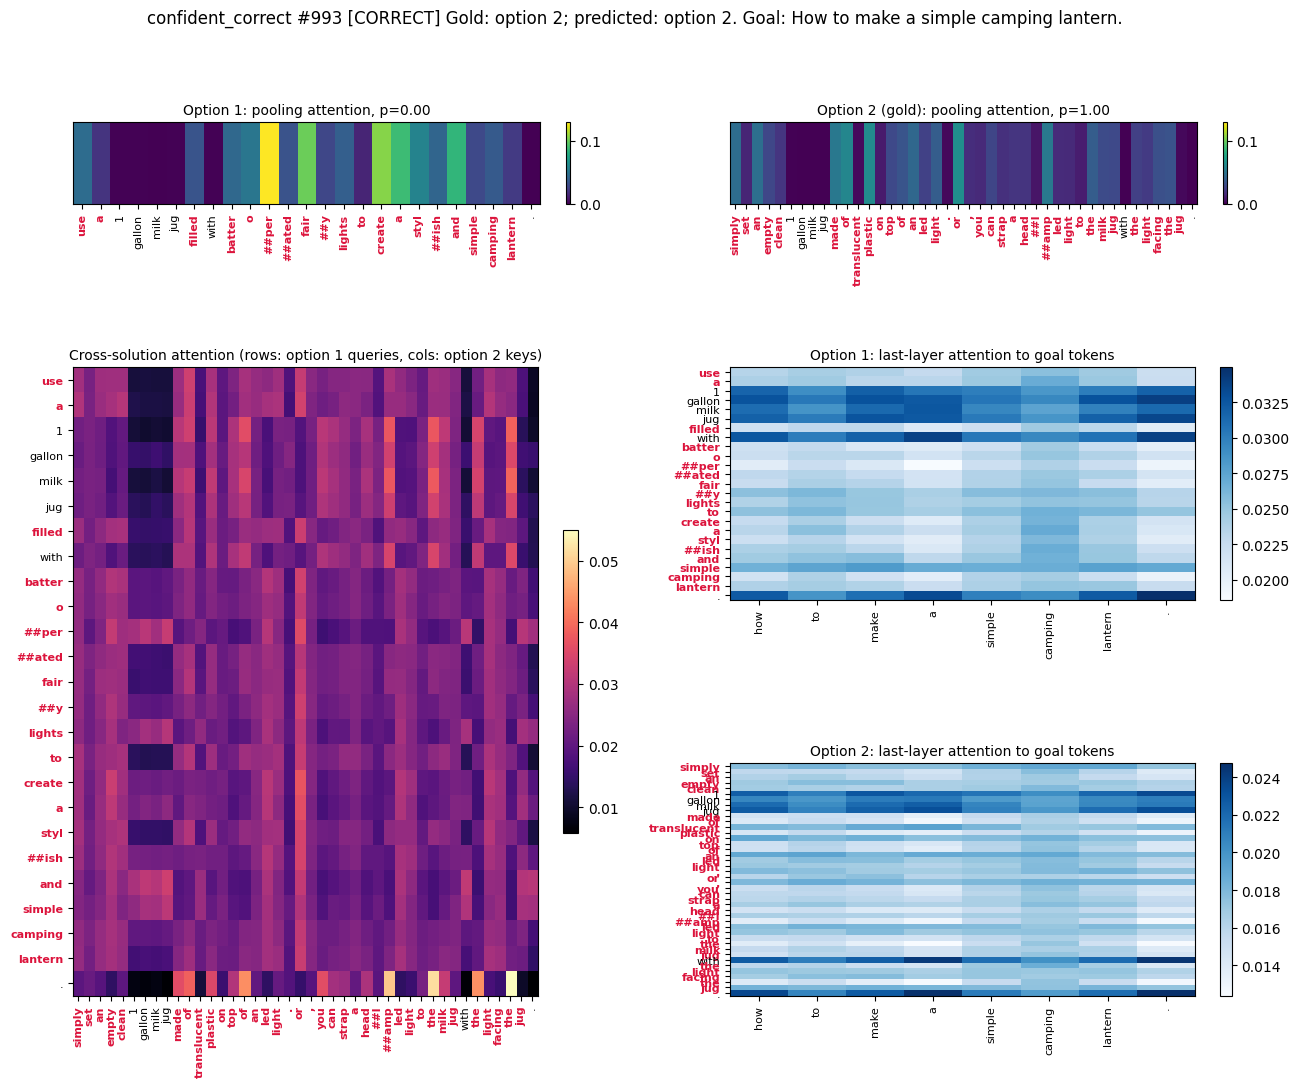

--- confident_correct | test item 1123 | gold = option 2
  goal: can you use any oil for frying foods?
  sol1: yes, as long as the varieties are not mixed, or mixed with water.
  sol2: If you use an inappropriate oil to deep-fry food, you could find that it ends up with a weird, off-putting taste


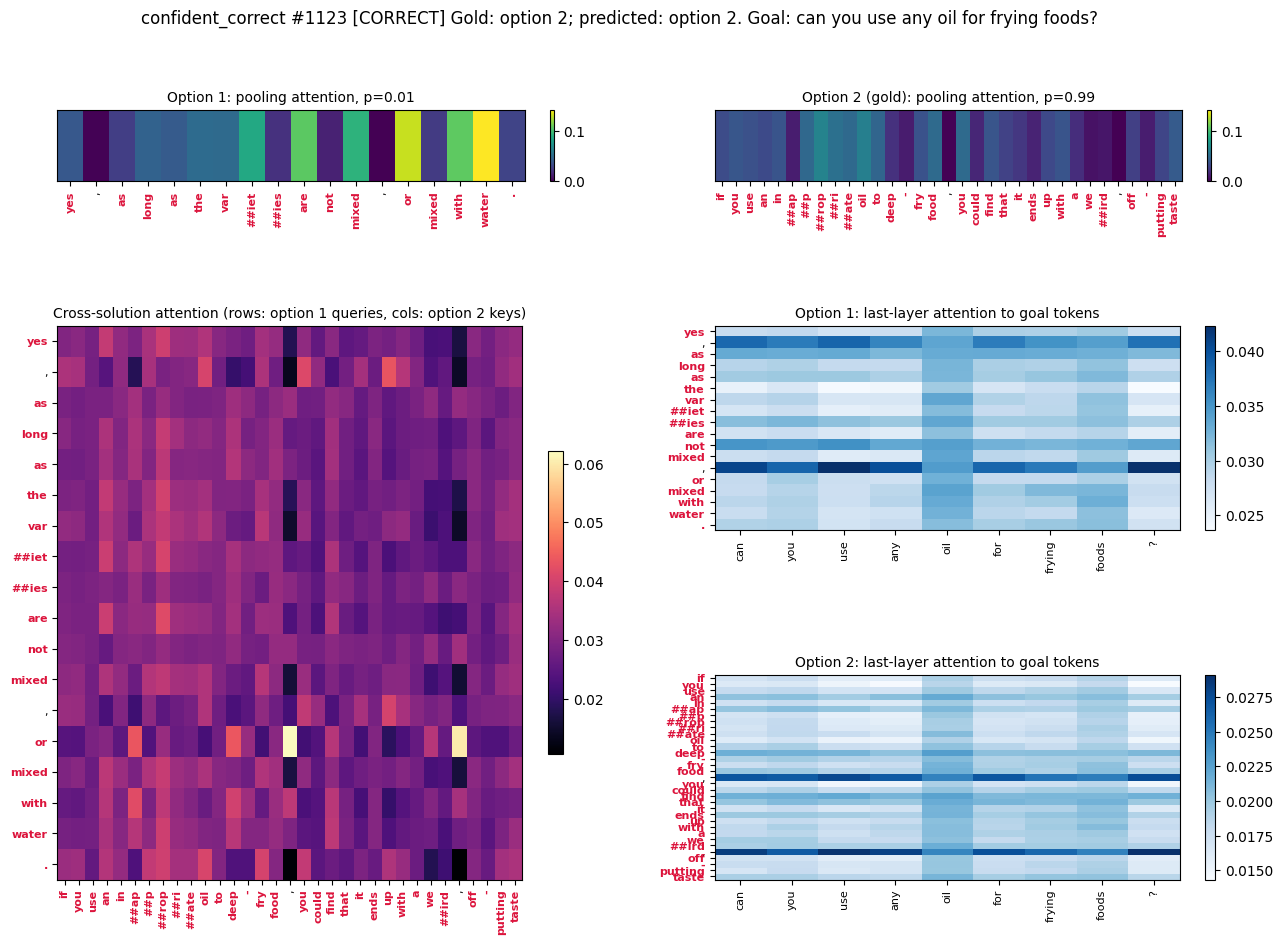

--- confident_wrong | test item 1282 | gold = option 1
  goal: Boil water for a cup of tea using a stove.
  sol1: Use a tea kettle, in this case a metal kettle on the stove, fill with a few cups of water. Place the kettle on the heat and bring to a boil. Shut the heat off and pour water into a tea cup.
  sol2: Use a tea kettle, in this case a metal kettle on the stove, fill with a 1/2 cup of water. Place the kettle on the heat and bring to a boil. Shut the heat off and pour water into a tea cup. Fill the kettle with 1/2 cup of water and bring to a boil again.


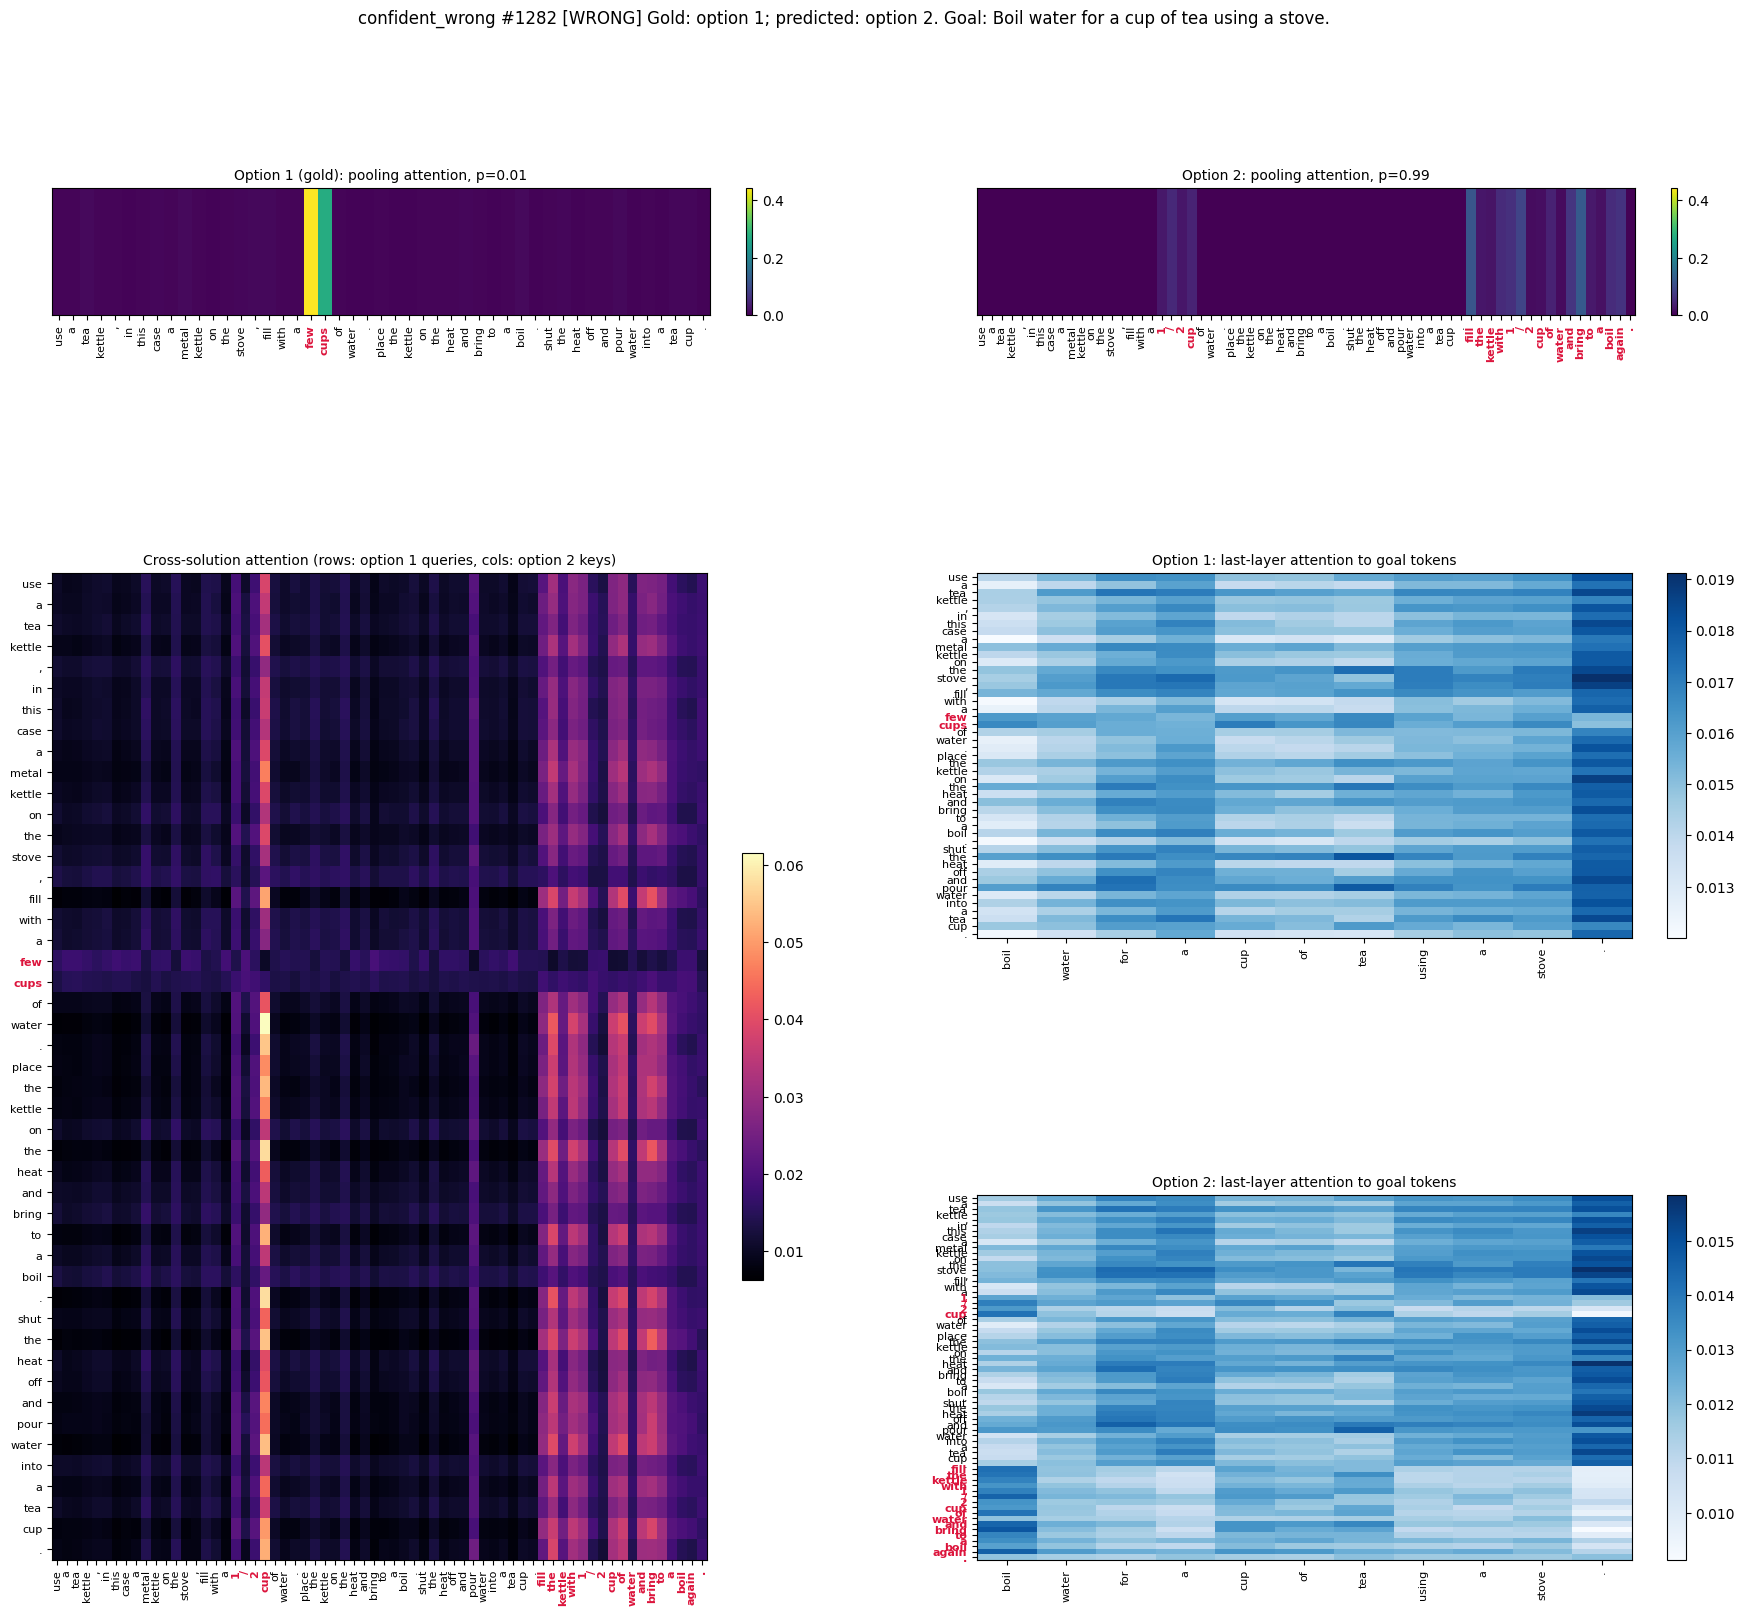

--- confident_wrong | test item 747 | gold = option 2
  goal: adding scents to lotion bars
  sol1: grate the wax and melt, in a double boiler. Add the oils to the water in the bottom of the double boiler.
  sol2: once the lotion and wax have melted, and reached the trace stage, add the scented oils and stir to combine.


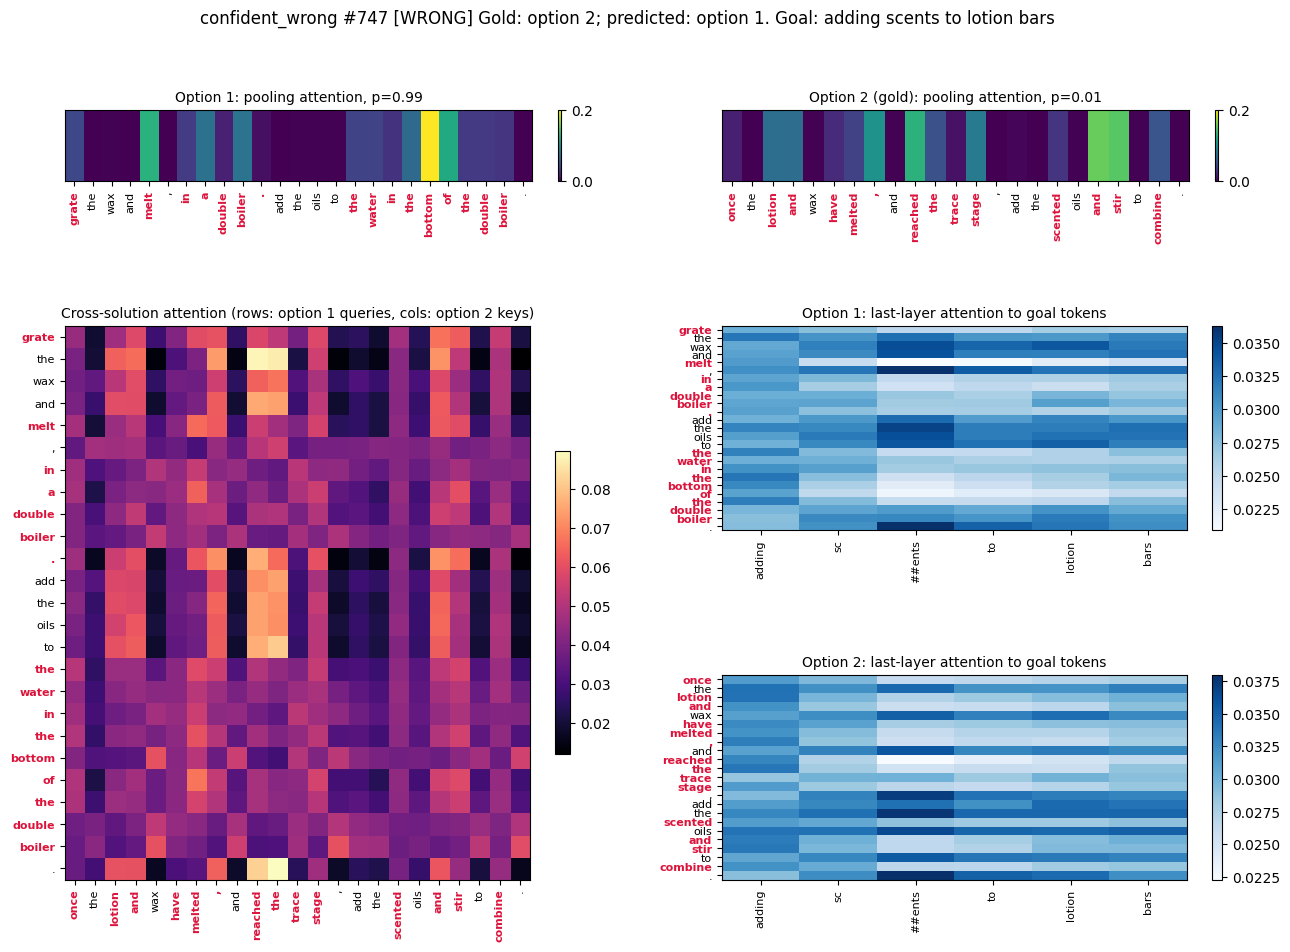

In [ ]:
for kind in ("confident_correct", "confident_wrong"):
    for i in CASES[kind]:
        r = DATA["test"][i]
        print(f"--- {kind} | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
        plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"{kind} #{i}",
                            save_path=os.path.join(CFG.out_dir, "figures", f"{kind}_{i}.png"))

--- uncertain | test item 1724 | gold = option 2
  goal: To safely sleep with your baby in your bed,
  sol1: lay under a light cover only, keep yourself between them and the other parent and put pillows on the ground by the bed in case the baby falls off.
  sol2: lay on top of the cover, keep yourself between them and the other parent or preferably have the other parent sleep somewhere else, and put up a barrier to keep the baby from falling onto the floor.


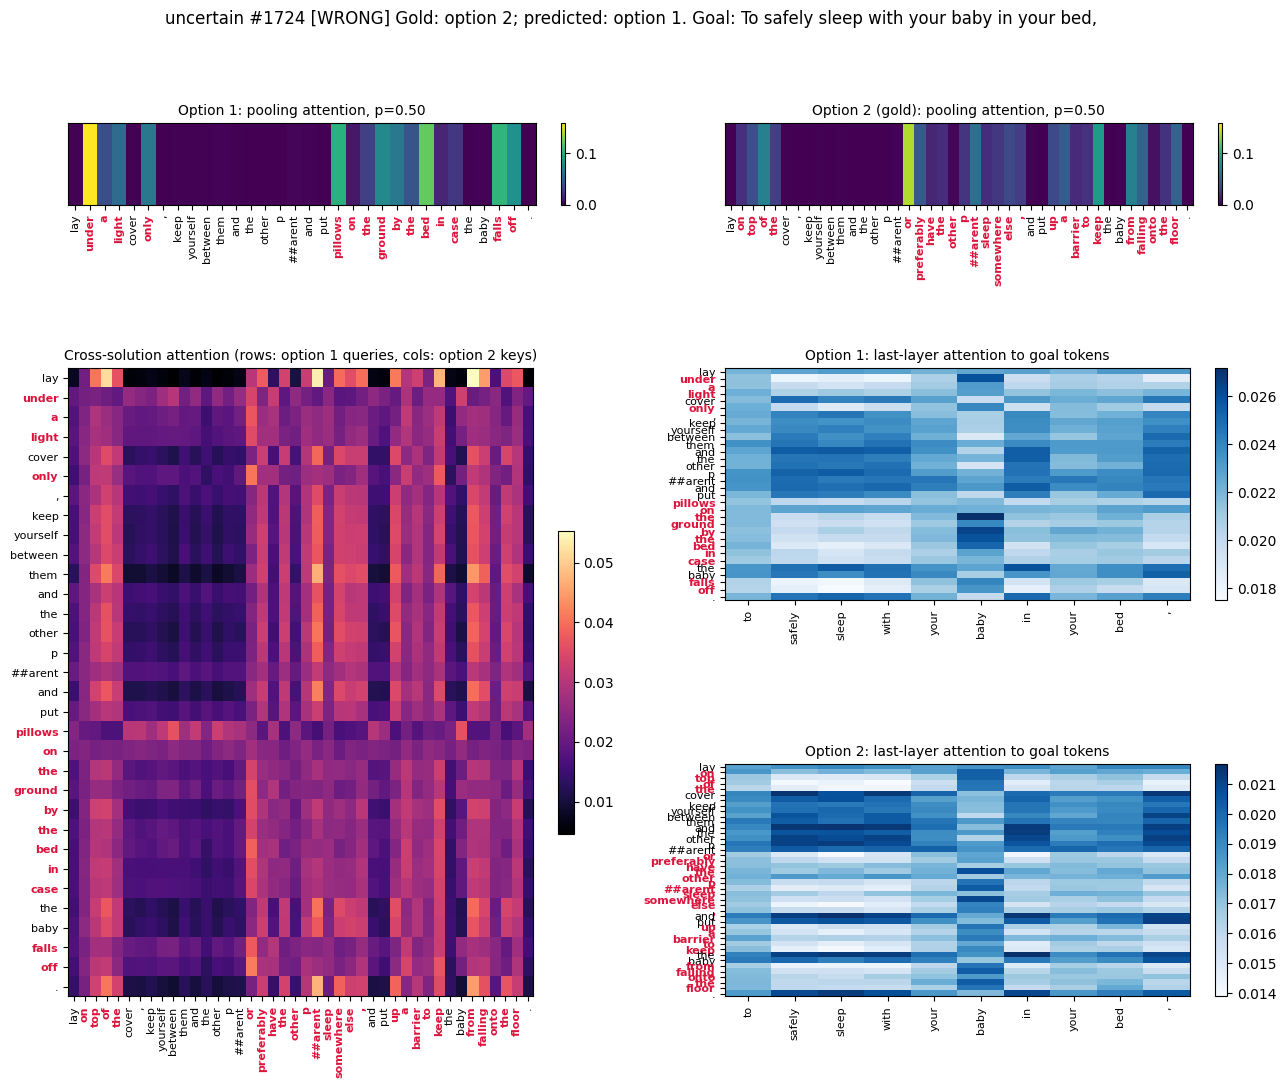

In [ ]:
i = CASES["uncertain"][0]
r = DATA["test"][i]
print(f"--- uncertain | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
_ = plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"uncertain #{i}",
                        save_path=os.path.join(CFG.out_dir, "figures", f"uncertain_{i}.png"))

### Does attention focus on the differing tokens, and does that relate to correctness?
For every test item we measure the share of pooling attention that falls on difference-tagged tokens and compare it with the share those tokens would get under uniform attention, separately for correct and wrong predictions.

**Control (revision 2).** The pooling bias for differing tokens is *initialised* at 1.0, so part of this focus is built in before any training. We therefore also measure the mass (a) of the same trained model with the tag bias set to 0, i.e. the focus coming only from the learned token representations, and (b) of an untrained model, i.e. the focus produced by the initial bias alone. The *diff-bias prior 0* ablation (Step 3) is the matching training-time control.

learned pooling tag bias [other, shared, diff]: [ 0.    -0.019  1.019]
mean attention mass on differing tokens: 0.859 (uniform-attention reference 0.248)
  correct predictions: 0.847 | wrong predictions: 0.877
  Mann-Whitney U (correct vs wrong): p = 1.595e-05


,mean pooling mass on differing tokens
trained,0.859
"trained, tag bias = 0",0.751
untrained (initialisation),0.389
uniform attention (reference),0.248


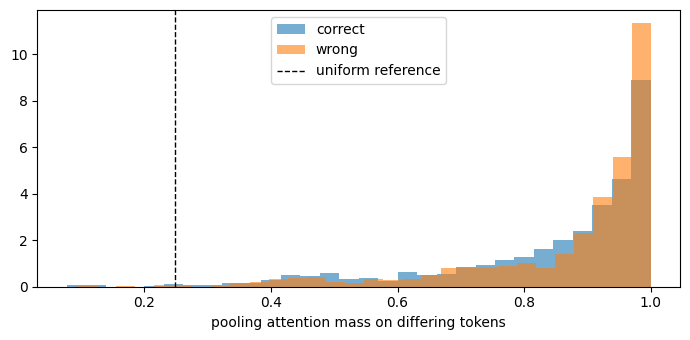

In [ ]:
from scipy.stats import mannwhitneyu
test_loader = make_loader(DATA["test_ds"], BEST_CFG, False, DEVICE)
mass, correct = diff_attention_mass(DACT_BEST, test_loader, DEVICE)
uniform = diff_token_share(test_loader)
print(f"learned pooling tag bias [other, shared, diff]: {DACT_BEST.pool.tag_bias.detach().cpu().numpy().round(3)}")
print(f"mean attention mass on differing tokens: {mass.mean():.3f} (uniform-attention reference {uniform.mean():.3f})")
print(f"  correct predictions: {mass[correct].mean():.3f} | wrong predictions: {mass[~correct].mean():.3f}")
print("  Mann-Whitney U (correct vs wrong): p = %.4g" % mannwhitneyu(mass[correct], mass[~correct]).pvalue)
CONTROLS = diff_attention_controls(DACT_BEST, BEST_CFG, DATA["vocab_size"], test_loader, DEVICE)
CONTROLS["uniform attention (reference)"] = float(uniform.mean())
display(pd.Series(CONTROLS, name="mean pooling mass on differing tokens").round(3).to_frame())
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(mass[correct], bins=30, alpha=0.6, density=True, label="correct")
ax.hist(mass[~correct], bins=30, alpha=0.6, density=True, label="wrong")
ax.axvline(uniform.mean(), c="k", ls="--", lw=1, label="uniform reference")
ax.set_xlabel("pooling attention mass on differing tokens"); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "figures", "diff_attention_mass.png"), dpi=120); plt.show()

### Why does DACT not beat a bag-of-words baseline? Two testable explanations
TF-IDF + LR scores at least as well as DACT on test, on a task built around lexical differences. We test two explanations on the **validation** split (no test data is used for this diagnosis):

* **H1: the pooling does not select.** If the pooling weights are close to uniform (normalised entropy near 1), the scorer sees an average over the solution, not the decisive words.
* **H2: the difference signal does not survive the encoder.** A linear probe tries to tell differing from shared solution tokens at every layer. For DACT the tag is injected at the input, so a probe score that falls with depth means the signal fades. For the vanilla Transformer (no tags), compare each layer with its *embedding* row: word identity alone already predicts some differing tokens (some words appear mostly in substituted spans), so only a rise above the embedding score shows that the encoder works out the difference from context, which is what the tags were meant to supply.

In [ ]:
val_loader = make_loader(DATA["val_ds"], BEST_CFG, False, DEVICE)
ent, ent_correct = pooling_entropy(DACT_BEST, val_loader, DEVICE)
print(f"H1  normalised pooling entropy (1 = uniform): mean {ent.mean():.3f} | correct {ent[ent_correct].mean():.3f} "
      f"| wrong {ent[~ent_correct].mean():.3f} | Mann-Whitney p = {mannwhitneyu(ent[ent_correct], ent[~ent_correct]).pvalue:.3g}")

van_res = EXP["vanilla Transformer"]
van_cfg = Config(**van_res["config"])
VANILLA = DACT(van_cfg, DATA["vocab_size"]).to(DEVICE)
VANILLA.load_state_dict(torch.load(max(van_res["runs"], key=lambda r: r["val_acc"])["ckpt"], map_location=DEVICE))
probe_train = make_loader(DATA["train_ds"], BEST_CFG, True, DEVICE)
PROBE = pd.DataFrame({
    "DACT (tags injected)": pd.DataFrame(diff_probe_by_layer(DACT_BEST, probe_train, val_loader, DEVICE)).set_index("layer")["balanced acc"],
    "vanilla (no tags)": pd.DataFrame(diff_probe_by_layer(VANILLA, probe_train, val_loader, DEVICE)).set_index("layer")["balanced acc"],
})
PROBE.to_csv(os.path.join(CFG.out_dir, "results", "diff_probe_by_layer.csv"))
print("H2  linear-probe balanced accuracy for 'differing vs shared' solution tokens (0.5 = chance):")
display(PROBE.round(3))
del VANILLA

H1  normalised pooling entropy (1 = uniform): mean 0.487 | correct 0.492 | wrong 0.479 | Mann-Whitney p = 0.183


H2  linear-probe balanced accuracy for 'differing vs shared' solution tokens (0.5 = chance):


,DACT (tags injected),vanilla (no tags)
layer,,
embedding,1.0,0.590
encoder 1,1.0,0.591
encoder 2,1.0,0.599


### Qualitative discussion

**Is the focus on differing tokens learned or built in?** The trained model puts **85.9 %** of its pooling attention on the differing tokens, which make up only 24.8 % of solution tokens. The controls separate the sources of this focus:
* an **untrained** model with the same initial bias puts 38.9 % there: the built-in prior alone gives only a modest focus;
* the **trained model with the tag bias set to 0** still puts **75.1 %** there: most of the focus comes from what the pooling scorer learned about the token representations, not from the bias;
* the bias itself hardly moved in training (differing tokens 1.0 → 1.019, shared tokens 0 → −0.019).

So the focus is genuinely learned, which is also why *diff-bias prior 0* changes nothing. Wrong predictions put slightly *more* attention on the differing tokens than correct ones (87.7 % vs 84.7 %, Mann-Whitney p < 0.001): **looking at the right tokens is not the bottleneck; judging them is.**

**Why the neural part alone does not beat bag-of-words (validation split).**
* *H1 (the pooling does not select)* is rejected: the normalised pooling entropy is 0.49 (1 = uniform), for correct and wrong predictions alike (0.49 vs 0.48, p = 0.18).
* *H2 (the difference signal is missing)*: in the vanilla Transformer a linear probe separates differing from shared tokens with 59.0 % balanced accuracy at the embedding layer and at most 59.9 % after the encoder layers: without tags the encoder barely works out *where* the options differ. In DACT the injected tag stays perfectly decodable in every layer (100 %), and removing the tags costs 1.3 / 1.0 points. The tags therefore supply information the encoder does not learn by itself, and the lexical head supplies direct word-level evidence the encoder uses only indirectly; neither provides the physical knowledge that the pretrained baselines bring.

**A side effect of the lexical head: over-confidence on long differing spans.** Three of the four most confident predictions (p ≥ 0.99) are pairs of options that **differ in most of their words**, and the fourth (the tea-kettle failure below) is a near-duplicate pair in which the wrong option adds a whole extra sentence. The lexical score is a *sum* of n-gram weights, so a long differing span produces a large score difference whether or not the evidence is right; calibration of the head (e.g. length normalisation) is a natural next step.

**Success: "How to make a simple camping lantern", *milk jug on top of an LED light / strapped headlamp* ✓ vs *milk jug filled with batter-operated fairy lights* (p = 1.00)**, and similarly "Can you use any oil for frying foods?", *an inappropriate oil gives an off-putting taste* ✓ vs *yes, as long as the varieties are not mixed* (p = 0.99). Nearly every token differs, so the difference tags carry little information; the pooling spreads over the whole solution (*fair*, *create*, *styl* vs *plastic*, *made of*, *head ##lamp*), and the decision rests on which words and phrases were associated with plausible solutions in training.

**Failure 1: "Boil water for a cup of tea using a stove", *fill the kettle with a few cups of water* (gold) vs *fill it with 1/2 cup … then fill it with 1/2 cup again and bring to a boil again* (p = 0.99 for the wrong option).** The pooling of the gold option puts almost all its weight on the only differing words, *few cups* (0.44 and 0.27), and the cross-solution attention aligns the shared text with *1/2 cup* and the extra sentence of the rival, so the model finds both differences. It still prefers the wrong option: its extra sentence (*fill the kettle … bring to a boil again*) is a long run of cooking words that the lexical head scores highly, and nothing in the model knows that boiling half a cup twice is a roundabout way to make one cup of tea.

**Failure 2: "Adding scents to lotion bars", *grate the wax, melt in a double boiler, add the oils to the water in the bottom of the boiler* vs *once melted and at trace stage, add the scented oils and stir* (gold) (p = 0.99 for the wrong option).** The pooling of option 1 peaks on *bottom*, *melt* and *boiler*, the part that makes it wrong (oil into the water bath), and of option 2 on *stir*, *reached*, *stage* and *lotion*. The model has no way to know that oil added to the water bath never reaches the lotion; the familiar cooking vocabulary of option 1 wins.

**Uncertain case: "To safely sleep with your baby in your bed", *lie under a light cover, put pillows on the ground in case the baby falls off* vs *lie on top of the cover, have the other parent sleep elsewhere, put up a barrier* (gold) (p = 0.50).** Both options differ in many places, and the pooling selects the decisive spans on both sides (*under*, *pillows*, *ground*, *falls off* vs *or (preferably)*, *keep*, *from*, *floor*), but the scores tie. Choosing correctly needs infant-safety knowledge (loose covers and pillows are a suffocation risk, a barrier prevents falls), which word statistics from 14.5 k items do not provide.

**Summary.** DACT learns to concentrate on the words where the options differ, the difference tags supply information the encoder does not discover alone, and the lexical head adds direct word-level evidence, which together make it the best from-scratch model. The remaining errors come from judging the decisive words without physical or safety knowledge (*oil into the water bath*, *covers and pillows near a baby*) and from the head's over-confidence on long differing spans (*tea kettle*). Pretraining (B3/B4) addresses the first; length normalisation of the lexical score addresses the second.

## Consistency check
The marking guide penalises differences between the report, the code and the logs. This cell checks that the saved result files match the tables above and that every training run left a log.

In [ ]:
import glob, subprocess
saved = pd.read_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"))
assert np.allclose(saved["test acc"], RESULTS["test acc"]) and list(saved["model"]) == list(RESULTS["model"]), "final_results.csv is stale"
for name, res in EXP.items():
    with open(os.path.join(CFG.out_dir, "results", f"{res['name']}_val.json")) as f:
        assert abs(json.load(f)["val"]["mean"] - res["val"]["mean"]) < 1e-9, f"{name}: val json differs"
    for r in res["runs"]:
        assert os.path.isfile(os.path.join(CFG.out_dir, "logs", f"{res['name']}_seed{r['seed']}.jsonl")), f"missing log for {name}"
print(f"OK: {len(RESULTS)} result rows, {sum(len(r['runs']) for r in EXP.values())} training runs with logs, "
      f"{len(glob.glob(os.path.join(CFG.out_dir, 'logs', '*.jsonl')))} log files")
if os.path.isfile("tools/sync_notebook.py"):   # only when run from a checkout of the repository
    print(subprocess.run([sys.executable, "tools/sync_notebook.py", "--check"], capture_output=True, text=True).stdout)

OK: 14 result rows, 30 training runs with logs, 40 log files


In [ ]:
# Persist logs, results and figures (checkpoints excluded to save space): copy to Google Drive when it is mounted,
# and on Colab also pack them into outputs.zip and download it to the browser's computer.
import shutil
if not SMOKE and os.path.isdir("/content/drive/MyDrive"):
    dst = "/content/drive/MyDrive/Group69/outputs"
    shutil.copytree(CFG.out_dir, dst, dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    print("copied to", dst)
if not SMOKE and _in_colab():
    shutil.copytree(CFG.out_dir, "/tmp/outputs", dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    archive = shutil.make_archive("/content/outputs", "zip", "/tmp", "outputs")
    print("packed", archive, f"({os.path.getsize(archive) / 1e6:.1f} MB)")
    from google.colab import files
    files.download(archive)
print(sorted(os.listdir(os.path.join(CFG.out_dir, "logs")))[:10], "...")

packed /content/outputs.zip (15.0 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['B3_roberta-base_seed42.jsonl', 'B3_roberta-base_seed43.jsonl', 'B3_roberta-base_seed44.jsonl', 'abl0_seed42.jsonl', 'abl0_seed43.jsonl', 'abl0_seed44.jsonl', 'abl1_seed42.jsonl', 'abl1_seed43.jsonl', 'abl1_seed44.jsonl', 'abl2_seed42.jsonl'] ...


# References
Full BibTeX entries are in `references.bib` (used for the report).

* Bisk, Y., Zellers, R., Le Bras, R., Gao, J., & Choi, Y. (2020). PIQA: Reasoning about Physical Commonsense in Natural Language. *AAAI*.
* Vaswani, A. et al. (2017). Attention Is All You Need. *NeurIPS*.
* Xiong, R. et al. (2020). On Layer Normalization in the Transformer Architecture. *ICML* (pre-LN encoder blocks).
* Chen, Q. et al. (2017). Enhanced LSTM for Natural Language Inference. *ACL* (ESIM `[h; c; h−c; h⊙c]` fusion used in the cross-solution block).
* Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. *ICLR* (additive attention pooling).
* Devlin, J. et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL* (masked-LM objective of the warm-up).
* Liu, Y. et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv:1907.11692* (baseline B3).
* Qwen Team (2024). Qwen2.5 Technical Report. *arXiv:2412.15115* (baseline B4).
* Sennrich, R., Haddow, B., & Birch, A. (2016). Neural Machine Translation of Rare Words with Subword Units. *ACL* (BPE tokenizer).
* Gururangan, S. et al. (2018). Annotation Artifacts in Natural Language Inference Data. *NAACL* (lexical shortcuts, cf. the TF-IDF baseline).
* Jain, S., & Wallace, B. C. (2019). Attention is not Explanation. *NAACL*; Wiegreffe, S., & Pinter, Y. (2019). Attention is not not Explanation. *EMNLP* (limits of reading attention maps).
* McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika*; Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*.
* Cheng, H.-T. et al. (2016). Wide & Deep Learning for Recommender Systems. *DLRS workshop* (jointly trained sparse "wide" and deep components, the idea behind the lexical head).
* Dodge, J. et al. (2020). Fine-Tuning Pretrained Language Models: Weight Initializations, Data Orders, and Early Stopping. *arXiv:2002.06305* (seed instability of B3).
* Dror, R. et al. (2018). The Hitchhiker's Guide to Testing Statistical Significance in Natural Language Processing. *ACL*.